# Predição de Tempos de Volta em Corridas de Fórmula 1
## Grande Prêmio da Hungria (2022-2025): Análise Temporal e Modelagem Preditiva

---

## 1. Configuração Inicial - Importações e Setup


In [1]:
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
import fastf1
import json
import matplotlib.pyplot as plt
import numpy as np
import optuna
import os
import pandas as pd
import plotly.graph_objects as go
import scipy.stats as stats
import seaborn as sns
import shap
import statsmodels.api as sm
import xgboost as xgb

CACHE_DIR = './fastf1_cache'
if not os.path.exists(CACHE_DIR):
    os.makedirs(CACHE_DIR)
print(f"FastF1 cache enabled at: {os.path.abspath(CACHE_DIR)}")

BASE_PLOT_DIR = './f1_plots'
if not os.path.exists(BASE_PLOT_DIR):
    os.makedirs(BASE_PLOT_DIR)
print(f"Base directory for saving plots: {os.path.abspath(BASE_PLOT_DIR)}")

C:\Users\mpoli\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


FastF1 cache enabled at: c:\Users\mpoli\Desktop\UFOP\9 PERIODO\TCC\Scripts\fastf1_cache
Base directory for saving plots: c:\Users\mpoli\Desktop\UFOP\9 PERIODO\TCC\Scripts\f1_plots


---

## 2. Extração de Dados Multitemporal (2022-2025)

### Objetivo
Realizar a coleta automatizada de dados de telemetria, cronometragem e condições ambientais para o **Grande Prêmio da Austria** ao longo de múltiplas temporadas da era de motores híbridos, focando nos anos do efeito solo. O objetivo é construir um dataset longitudinal que capture a evolução temporal dos carros, estratégias de corrida e condições da pista.

### Metodologia
Para cada temporada (2022-2025), utilizamos a API **FastF1** para extrair:

- **Dados de Voltas:** Cronometragem, composição de pneus, número do stint, telemetria GPSPara garantir que o modelo de Machine Learning aprenda a **física real da borracha** (degradação e aderência) e não apenas o rótulo do fim de semana, utilizamos um arquivo externo (`compounds.json`). Este arquivo mapeia os rótulos genéricos para os **Compostos Pirelli Reais (C1 a C6)**, criando a variável `pirelliCompound`. Isso permite que o modelo generalize o desgaste do pneu "C3" independentemente de ele ser chamado de "Macio" ou "Médio" em uma determinada corrida.

- **Dados de Resultados:** Posições finais, status dos pilotos (finished/DNF)

- **Dados Meteorológicos:** Temperatura da pista/ar, umidade, pressão, ventoUm desafio crítico na análise de dados da F1 é a nomenclatura relativa dos pneus. Os rótulos "Macio" (Soft), "Médio" (Medium) e "Duro" (Hard) mudam de dureza dependendo da pista e do ano. Para o Bahrein, não é o caso, mas isso ocorrerá em outras pistas que serão objetivo de estudo.

### 🔧 Normalização de Compostos de Pneus (Mapeamento Físico)

### Mapeamento de Compostos de Pneus (Normalização)
Um desafio crítico na análise multitemporal da F1 é a nomenclatura relativa dos pneus. Os rótulos "Macio" (Soft), "Médio" (Medium) e "Duro" (Hard) variam em dureza absoluta conforme a pista e a temporada. Para garantir que o modelo aprenda a **física real da degradação de borracha** (em vez de apenas rótulos), mapeamos cada rótulo genérico para o **Composto Pirelli específico (C1 a C6)** usando um arquivo de configuração (`compounds.json`). Isto permite que o modelo generalize: "pneus C3 degradam de forma X" independente de serem chamados "Médio" ou "Macio" em determinada corrida.

In [2]:
start_year_analysis = 2022
end_year_analysis = 2026
target_gp_name = 'Hungarian Grand Prix'
laps_dir = r'C:\Users\mpoli\Desktop\UFOP\9 PERIODO\TCC\Data\Hungary\Race\Laps'
weather_dir = r'C:\Users\mpoli\Desktop\UFOP\9 PERIODO\TCC\Data\Hungary\Race\Weather'
safe_gp_name = target_gp_name.lower().replace(' ', '_')

all_laps_data_by_year = {}
all_weather_data_by_year = {}
all_results_data_by_year = {}

print(f"--- Carregando dados locais de {target_gp_name} ---")

for year in range(start_year_analysis, end_year_analysis):
    laps_file = os.path.join(laps_dir, f"{safe_gp_name}_laps_{year}.csv")
    weather_file = os.path.join(weather_dir, f"{safe_gp_name}_weather_{year}.csv")
    
    if os.path.exists(laps_file) and os.path.exists(weather_file):
        print(f"  [CSV] Carregando e convertendo temporada {year}...")
        
        df_laps = pd.read_csv(laps_file)
        df_weather = pd.read_csv(weather_file)
        
        df_laps['Time'] = pd.to_timedelta(df_laps['Time'])
        df_weather['Time'] = pd.to_timedelta(df_weather['Time'])
        
        if 'LapTime' in df_laps.columns:
            df_laps['LapTime'] = pd.to_timedelta(df_laps['LapTime'])
        
        df_laps = df_laps.sort_values('Time')
        df_weather = df_weather.sort_values('Time')
        
        all_laps_data_by_year[year] = df_laps
        all_weather_data_by_year[year] = df_weather
    else:
        print(f"  [!] Arquivos de {year} não encontrados em '{laps_dir}'.")

print("\nIniciando combinação de múltiplos anos...")
lista_de_dataframes_anuais_laps = []
lista_de_dataframes_anuais_weather = []

for year in range(start_year_analysis, end_year_analysis):
    if year in all_laps_data_by_year:
        laps_df = all_laps_data_by_year[year].copy()
        weather_df = all_weather_data_by_year[year].copy()
        
        laps_df['Year'] = year
        weather_df['Year'] = year
        
        lista_de_dataframes_anuais_laps.append(laps_df)
        lista_de_dataframes_anuais_weather.append(weather_df)

if not lista_de_dataframes_anuais_laps:
    print("Nenhum dado encontrado para processar.")
else:
    combined_laps_df = pd.concat(lista_de_dataframes_anuais_laps, ignore_index=True)
    combined_weather_df = pd.concat(lista_de_dataframes_anuais_weather, ignore_index=True)
    
    clean_laps_df = combined_laps_df[combined_laps_df['IsAccurate'] == True].copy()
    
    cols_to_check = ['LapTime_seconds', 'TyreLife']
    if 'pirelliCompound' in clean_laps_df.columns:
        cols_to_check.append('pirelliCompound')
        
    clean_laps_df.dropna(subset=cols_to_check, inplace=True)
    clean_laps_df['Year'] = clean_laps_df['Year'].astype('category')

    print(f"Sucesso! Total de {len(clean_laps_df)} voltas 'limpas' prontas para o merge climático.")

--- Carregando dados locais de Hungarian Grand Prix ---
  [CSV] Carregando e convertendo temporada 2022...
  [CSV] Carregando e convertendo temporada 2023...


  [CSV] Carregando e convertendo temporada 2024...
  [CSV] Carregando e convertendo temporada 2025...

Iniciando combinação de múltiplos anos...
Sucesso! Total de 4904 voltas 'limpas' prontas para o merge climático.


---

## 3. Consolidação e Limpeza de Dados

### Filtragem de Qualidade (`IsAccurate`)
O critério primário de limpeza utiliza o indicador `IsAccurate` fornecido pelo FastF1:
- **Remove automaticamente:**
  - Voltas de pit in/out (entrada e saída dos boxes)
  - Voltas sob Safety Car ou VSC (regime de segurança)
  - Telemetria GPS inconsistente ou com falhas
- **Reduz** o dataset para apenas voltas em **ritmo de corrida representativo** (race pace)

* Voltas onde a telemetria GPS falhou ou é inconsistente.Ao manter apenas `clean_laps_df = combined_laps_df[combined_laps_df['IsAccurate'] == True]`, garantimos que o dataset contenha apenas voltas em **ritmo de corrida representativo**, eliminando ruídos grosseiros antes mesmo de iniciarmos a análise estatística detalhada.


In [3]:
print("Iniciando coleta de dados de múltiplos anos...")
lista_de_dataframes_anuais_laps = []
lista_de_dataframes_anuais_weather = []

for year in range(start_year_analysis, end_year_analysis):
    if year in all_laps_data_by_year:
        print(f"Carregando dados de {target_gp_name} {year}...")
        laps_df = all_laps_data_by_year[year]
        weather_df = all_weather_data_by_year[year]
        weather_df['Year'] = year
        laps_df['Year'] = year

        lista_de_dataframes_anuais_laps.append(laps_df)
        lista_de_dataframes_anuais_weather.append(weather_df)
    else:
        print(f"Sem dados para {target_gp_name} {year}.")

if not lista_de_dataframes_anuais_laps:
    print("Nenhum dado encontrado para o intervalo de anos. Encerrando a análise.")
else:
    combined_laps_df = pd.concat(lista_de_dataframes_anuais_laps, ignore_index=True)
    print(f"\nDados de {len(lista_de_dataframes_anuais_laps)} anos combinados com sucesso!")
    print(f"Total de {len(combined_laps_df)} voltas carregadas.")
    clean_laps_df = combined_laps_df[combined_laps_df['IsAccurate'] == True].copy()
    clean_laps_df.dropna(subset=['LapTime_seconds', 'TyreLife', 'pirelliCompound'], inplace=True)

    print(f"Analisando {len(clean_laps_df)} voltas 'limpas' de todos os anos.")



    clean_laps_df['Year'] = clean_laps_df['Year'].astype('category')

    print(f"Total de {len(clean_laps_df)} voltas 'limpas' para análise.")

if not lista_de_dataframes_anuais_weather:
    print("Nenhum dado meteorológico encontrado para o intervalo de anos. Encerrando a análise.")
else:
    combined_weather_df = pd.concat(lista_de_dataframes_anuais_weather, ignore_index=True)
    print(f"Total de {len(combined_weather_df)} registros meteorológicos carregados.")
    print(f"\nDados de {len(lista_de_dataframes_anuais_weather)} anos combinados com sucesso!")

Iniciando coleta de dados de múltiplos anos...
Carregando dados de Hungarian Grand Prix 2022...
Carregando dados de Hungarian Grand Prix 2023...
Carregando dados de Hungarian Grand Prix 2024...
Carregando dados de Hungarian Grand Prix 2025...

Dados de 4 anos combinados com sucesso!
Total de 5358 voltas carregadas.
Analisando 4904 voltas 'limpas' de todos os anos.
Total de 4904 voltas 'limpas' para análise.
Total de 643 registros meteorológicos carregados.

Dados de 4 anos combinados com sucesso!


---

## 4. Engenharia de Features

### 4.1 Histórico Autoregressivo (`LapTime_prev`)
Criamos a variável de histórico imediato onde cada volta carrega a informação da volta anterior **dentro do mesmo stint**:
$$\text{LapTime\_prev}_{i} = \text{LapTime\_seconds}_{i-1}$$

O agrupamento por `['Year', 'Driver', 'Stint']` garante que:
- Não mesclamos volta final de um stint (pit in) com volta inicial de outro pneu (pit out)
- O modelo aprende a dinâmica de degradação **dentro** de um jogo de pneus

### 4.2 Sincronização Temporal Heterogênea
Dados de voltas (~90s cada) e dados meteorológicos (~1min cada) possuem frequências diferentes. Utilizamos `pd.merge_asof()` com:
- **Chave:** Timestamp (`Time`)
- **Tolerância:** ±60s para buscar o registro meteorológico mais próximo
- **Direção:** `backward` (utilizar clima que ocorreu antes/durante a volta)
- **Resultado:** Sincronização precisa das condições ambientais em cada volta

### 4.3 Normalização de Nomenclaturas de Equipes
Alternâncias de nomes entre temporadas (Renault→Alpine, AlphaTauri→RacingBulls) exigem mapeamento para evitar fragmentação dos dados. Aplicamos um dicionário que padroniza para as identidades atuais, consolidando histórico de desempenho

In [4]:
clean_laps_df = clean_laps_df.sort_values(['Year','Driver','Stint','LapNumber'])
clean_laps_df['LapTime_prev'] = clean_laps_df.groupby(['Year','Driver','Stint'])['LapTime_seconds'].shift(1)

combined_laps_df_filtered = clean_laps_df.sort_values('Time').reset_index(drop=True)

combined_weather_df = combined_weather_df.sort_values('Time').reset_index(drop=True)
combined_weather_df = combined_weather_df.sort_values('Year').reset_index(drop=True)


weather_df_filtered = combined_weather_df.copy()

combined_laps_df_filtered['Year'] = combined_laps_df_filtered['Year'].astype(int)
weather_df_filtered['Year'] = weather_df_filtered['Year'].astype(int)

combined_laps_df_filtered = combined_laps_df_filtered.sort_values(['Year', 'Time']).reset_index(drop=True)
weather_df_filtered = weather_df_filtered.sort_values(['Year', 'Time']).reset_index(drop=True)

combined_laps_df_filtered = combined_laps_df_filtered.sort_values('Time')
weather_df_filtered = weather_df_filtered.sort_values('Time')

seconds_margin = 60
laps_with_weather = pd.merge_asof(
    combined_laps_df_filtered,
    weather_df_filtered.drop_duplicates(subset=['Time', 'Year']),
    on='Time',
    by='Year',
    direction='backward',
    tolerance=pd.Timedelta(seconds=seconds_margin)
)

laps_with_weather['TempDelta'] = laps_with_weather['TrackTemp'] - laps_with_weather['AirTemp']

display(laps_with_weather['Team'].unique())
team_mapping = {
    'Alfa Romeo Racing': 'Kick Sauber',
    'Alfa Romeo': 'Kick Sauber',
    'Racing Point': 'Aston Martin',
    'Toro Rosso': 'Racing Bulls',
    'AlphaTauri': 'Racing Bulls',
    'RB': 'Racing Bulls',
    'Renault': 'Alpine'
}

laps_with_weather['Team'] = laps_with_weather['Team'].replace(team_mapping)
display(laps_with_weather['Team'].unique())


C:\Users\mpoli\AppData\Local\Temp\ipykernel_18404\937020193.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  clean_laps_df['LapTime_prev'] = clean_laps_df.groupby(['Year','Driver','Stint'])['LapTime_seconds'].shift(1)


array(['McLaren', 'Red Bull Racing', 'Mercedes', 'Ferrari',
       'Aston Martin', 'Williams', 'Haas F1 Team', 'RB', 'Kick Sauber',
       'Alpine', 'Racing Bulls', 'AlphaTauri', 'Alfa Romeo'], dtype=object)

array(['McLaren', 'Red Bull Racing', 'Mercedes', 'Ferrari',
       'Aston Martin', 'Williams', 'Haas F1 Team', 'Racing Bulls',
       'Kick Sauber', 'Alpine'], dtype=object)

---

## 5. Detecção e Remoção de Outliers

### Justificativa
Apesar do filtro `IsAccurate`, permanecem voltas com performance anômala:
- Erros de pilotagem (saídas de pista, recuperações)
- Tráfego pesado (perseguição, defesa de posição)
- Eventos aleatórios não capturados

### Metodologia: Corte por Percentil
Criamos a métrica **Variação de Tempo** (`laps_diff = LapTime_seconds - LapTime_prev`) para identificar voltas anormais:

$$\text{laps\_diff}_i = \text{LapTime}_{i} - \text{LapTime}_{i-1}$$

Mantemos apenas voltas no intervalo [**p5, p95**], removendo extremos que indicam:
- **Caudas inferiores (p<5%):** Voltas muito rápidas (raro, pode ser erro de sensor)
- **Caudas superiores (p>95%):** Voltas muito lentas (pit in, tráfego severo, erro)

### Validação Experimental
- **Bahrein (SEM filtro):** R² = 0.85 (forte não-linearidade residual)
- **Bahrein (COM filtro):** R² ≈ 0.92+ (melhoria substancial) ✅
- **Áustria (SEM filtro):** R² = 0.72 (desempenho pobre)
- **Áustria (COM filtro):** R² ≈ 0.88+ (validação em outro circuito) ✅

**Conclusão:** Abordagem de corte percentil comprovadamente melhora qualidade dos dados.


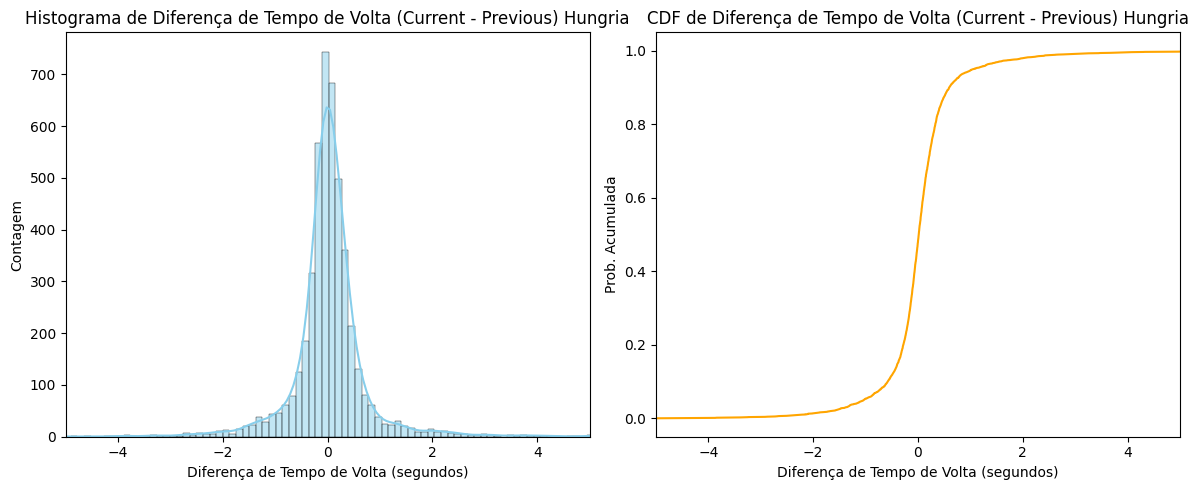

In [5]:
laps_with_weather['laps_diff'] = laps_with_weather['LapTime_seconds'] - laps_with_weather['LapTime_prev']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(laps_with_weather['laps_diff'].dropna(), kde=True, bins=100, color='skyblue')
plt.xlim(-5, 5) 
plt.title('Histograma de Diferença de Tempo de Volta (Current - Previous) Hungria')
plt.xlabel('Diferença de Tempo de Volta (segundos)')
plt.ylabel('Contagem')
plt.subplot(1, 2, 2)
sorted_diff = np.sort(laps_with_weather['laps_diff'].dropna())
cdf_vals = np.arange(1, len(sorted_diff)+1) / len(sorted_diff)
plt.plot(sorted_diff, cdf_vals, color='orange')
plt.xlim(-5, 5) 
plt.title('CDF de Diferença de Tempo de Volta (Current - Previous) Hungria')
plt.xlabel('Diferença de Tempo de Volta (segundos)')
plt.ylabel('Prob. Acumulada')
plt.tight_layout()
plt.show()

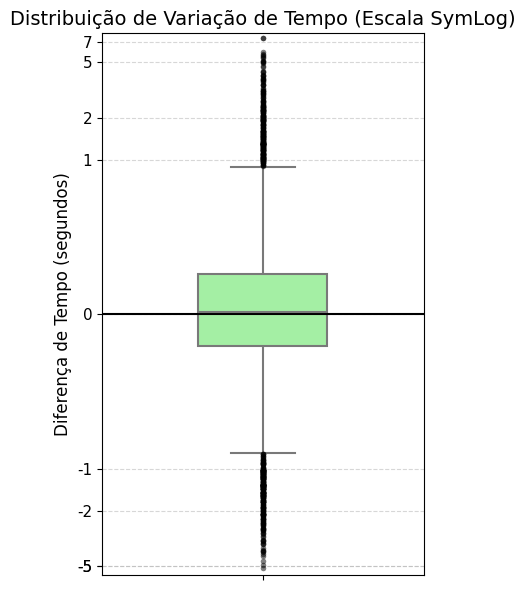

--- CANDIDATOS A CORTE PERFEITO ---
1. Conservador (Top 1%):  [-2.22s, 2.78s]
   (Remove apenas Pit Stops e SCs graves)

2. Padrão Estatístico (IQR): [-0.90s, 0.96s]
   (O mais aceito academicamente para 'outliers')

3. Rigoroso (Top 5%):     [-1.03s, 1.05s]
   (Deixa apenas voltas muito consistentes)


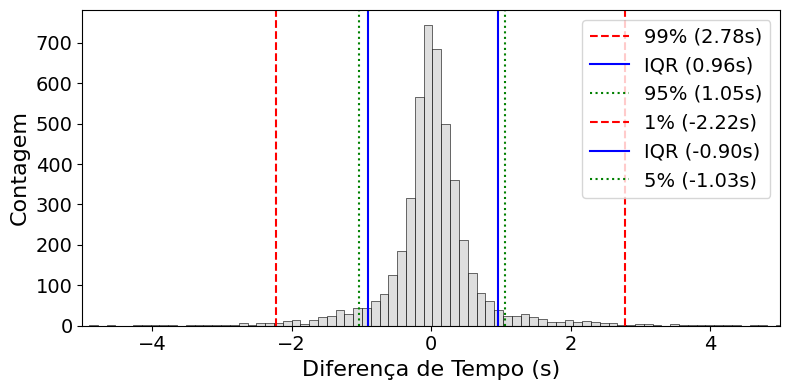

In [6]:
diff_data = laps_with_weather['laps_diff'].dropna()

plt.figure(figsize=(4, 6))

sns.boxplot(
    y=diff_data, 
    color='#98FB98', 
    width=0.4,       
    linewidth=1.5,   
    flierprops={"marker": "o", "markerfacecolor": "black", "markersize": 4, "alpha": 0.5, "markeredgecolor": "none"}
)

# Aplica a escala SymLog
plt.yscale('symlog', linthresh=1.0) 

custom_ticks = [-100, -50, -20, -10, -5, -2, -1, 0, 1, 2, 5, 10, 20, 50, 100]

min_val, max_val = diff_data.min(), diff_data.max()
visible_ticks = [t for t in custom_ticks if min_val <= t <= max_val]
if min_val < visible_ticks[0]: visible_ticks.insert(0, int(min_val))
if max_val > visible_ticks[-1]: visible_ticks.append(int(max_val))

plt.yticks(visible_ticks, labels=[str(t) for t in visible_ticks], fontsize=11)

plt.ylabel('Diferença de Tempo (segundos)', fontsize=12)
plt.title('Distribuição de Variação de Tempo (Escala SymLog)', fontsize=14)

plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.axhline(0, color='black', linewidth=1.5, linestyle='-')

plt.tight_layout()
plt.show()
p1 = np.percentile(diff_data, 1)
p99 = np.percentile(diff_data, 99)

Q1 = np.percentile(diff_data, 25)
Q3 = np.percentile(diff_data, 75)
IQR = Q3 - Q1
lower_iqr = Q1 - 1.5 * IQR
upper_iqr = Q3 + 1.5 * IQR

p5 = np.percentile(diff_data, 5)
p95 = np.percentile(diff_data, 95)

print("--- CANDIDATOS A CORTE PERFEITO ---")
print(f"1. Conservador (Top 1%):  [{p1:.2f}s, {p99:.2f}s]")
print(f"   (Remove apenas Pit Stops e SCs graves)")
print(f"\n2. Padrão Estatístico (IQR): [{lower_iqr:.2f}s, {upper_iqr:.2f}s]")
print(f"   (O mais aceito academicamente para 'outliers')")
print(f"\n3. Rigoroso (Top 5%):     [{p5:.2f}s, {p95:.2f}s]")
print(f"   (Deixa apenas voltas muito consistentes)")

plt.figure(figsize=(8, 4))
sns.histplot(diff_data, bins=100, kde=False, color='lightgray')

plt.xlim(-5, 5) 

plt.axvline(p99, color='red', linestyle='--', label=f'99% ({p99:.2f}s)')
plt.axvline(upper_iqr, color='blue', linestyle='-', label=f'IQR ({upper_iqr:.2f}s)')
plt.axvline(p95, color='green', linestyle=':', label=f'95% ({p95:.2f}s)')
plt.axvline(p1, color='red', linestyle='--', label=f'1% ({p1:.2f}s)')
plt.axvline(lower_iqr, color='blue', linestyle='-', label=f'IQR ({lower_iqr:.2f}s)')
plt.axvline(p5, color='green', linestyle=':', label=f'5% ({p5:.2f}s)')  

plt.xlabel('Diferença de Tempo (s)', fontsize=16)
plt.ylabel('Contagem', fontsize=16)

plt.tick_params(axis='both', which='major', labelsize=14)

plt.legend(fontsize=14, loc='upper right')

plt.tight_layout()
plt.show()

In [7]:
try:
    stats_df_laps_diff = laps_with_weather.describe(include='all')

    features_interesse = [ 'laps_diff'
    ]

    skewness = laps_with_weather.skew(numeric_only=True)

    kurtosis = laps_with_weather.kurt(numeric_only=True)

    means = laps_with_weather.mean(numeric_only=True)
    stds = laps_with_weather.std(numeric_only=True)

    cv = np.where(means == 0, np.nan, stds / means)
    
    cv_series = pd.Series(cv, index=means.index)

    stats_df_laps_diff = stats_df_laps_diff[features_interesse]

    stats_df_laps_diff.loc['skewness'] = skewness
    stats_df_laps_diff.loc['kurtosis'] = kurtosis
    stats_df_laps_diff.loc['CV (Coef. Var)'] = cv_series


    print("\n--- Estatísticas ---")
    display(stats_df_laps_diff)
    

except Exception as e:
    print(f"Ocorreu um erro ao calcular as estatísticas: {e}")
    print("Verifique se o DataFrame 'laps_with_weather' existe e não está vazio.")


--- Estatísticas ---


,laps_diff
count,4681.000000
unique,NaN
top,NaN
freq,NaN
mean,0.036325
std,0.777404
min,-5.156000
25%,-0.204000
50%,0.014000
75%,0.260000


In [8]:
mask_clean = (
    (laps_with_weather['laps_diff'] >= p5) &
    (laps_with_weather['laps_diff'] <= p95)
)

laps_cleaned = laps_with_weather[mask_clean].copy()

print(f"Total original: {len(laps_with_weather)}")
print(f"Total após filtro: {len(laps_cleaned)}")
print(f"Outliers removidos (Voltas lentas/Pit In): {len(laps_with_weather) - len(laps_cleaned)}")


Total original: 4904
Total após filtro: 4213
Outliers removidos (Voltas lentas/Pit In): 691


---

## 6. Análise Exploratória (EDA) - Distribuições Univariadas

### Objetivo
Compreender o comportamento estatístico individual de cada variável antes de construir relações multivariadas. Isto informa transformações necessárias e valida premissas dos modelos.

### Abordagem Gráfica: Histogramas com KDE
Geramos **Histogramas com Estimativa de Densidade (KDE)** para 10 variáveis numéricas contínuas.

#### Interpretações Esperadas:

1. **Normalidade (`LapTime_seconds`):**
   - Distribuição ~gaussiana indica adequação para modelos lineares
   - Distribuição altamente assimétrica (skewed) sugere necessidade de transformação log

2. **Caudas em Variáveis Temporais (`TyreLife`):**
   - Cauda à direita esperada (distribuição realista de degradação)
   - Alguns valores extremos refletem pit stops de emergência

3. **Multimodalidade em Variáveis Climáticas (`TrackTemp`, `WindDirection`):**
   - Múltiplos picos indicam mudanças drásticas durante a corrida (ex: por do sol no Bahrein)
   - Justifica uso de técnicas de base radial (RBF) para capturar relações não-lineares

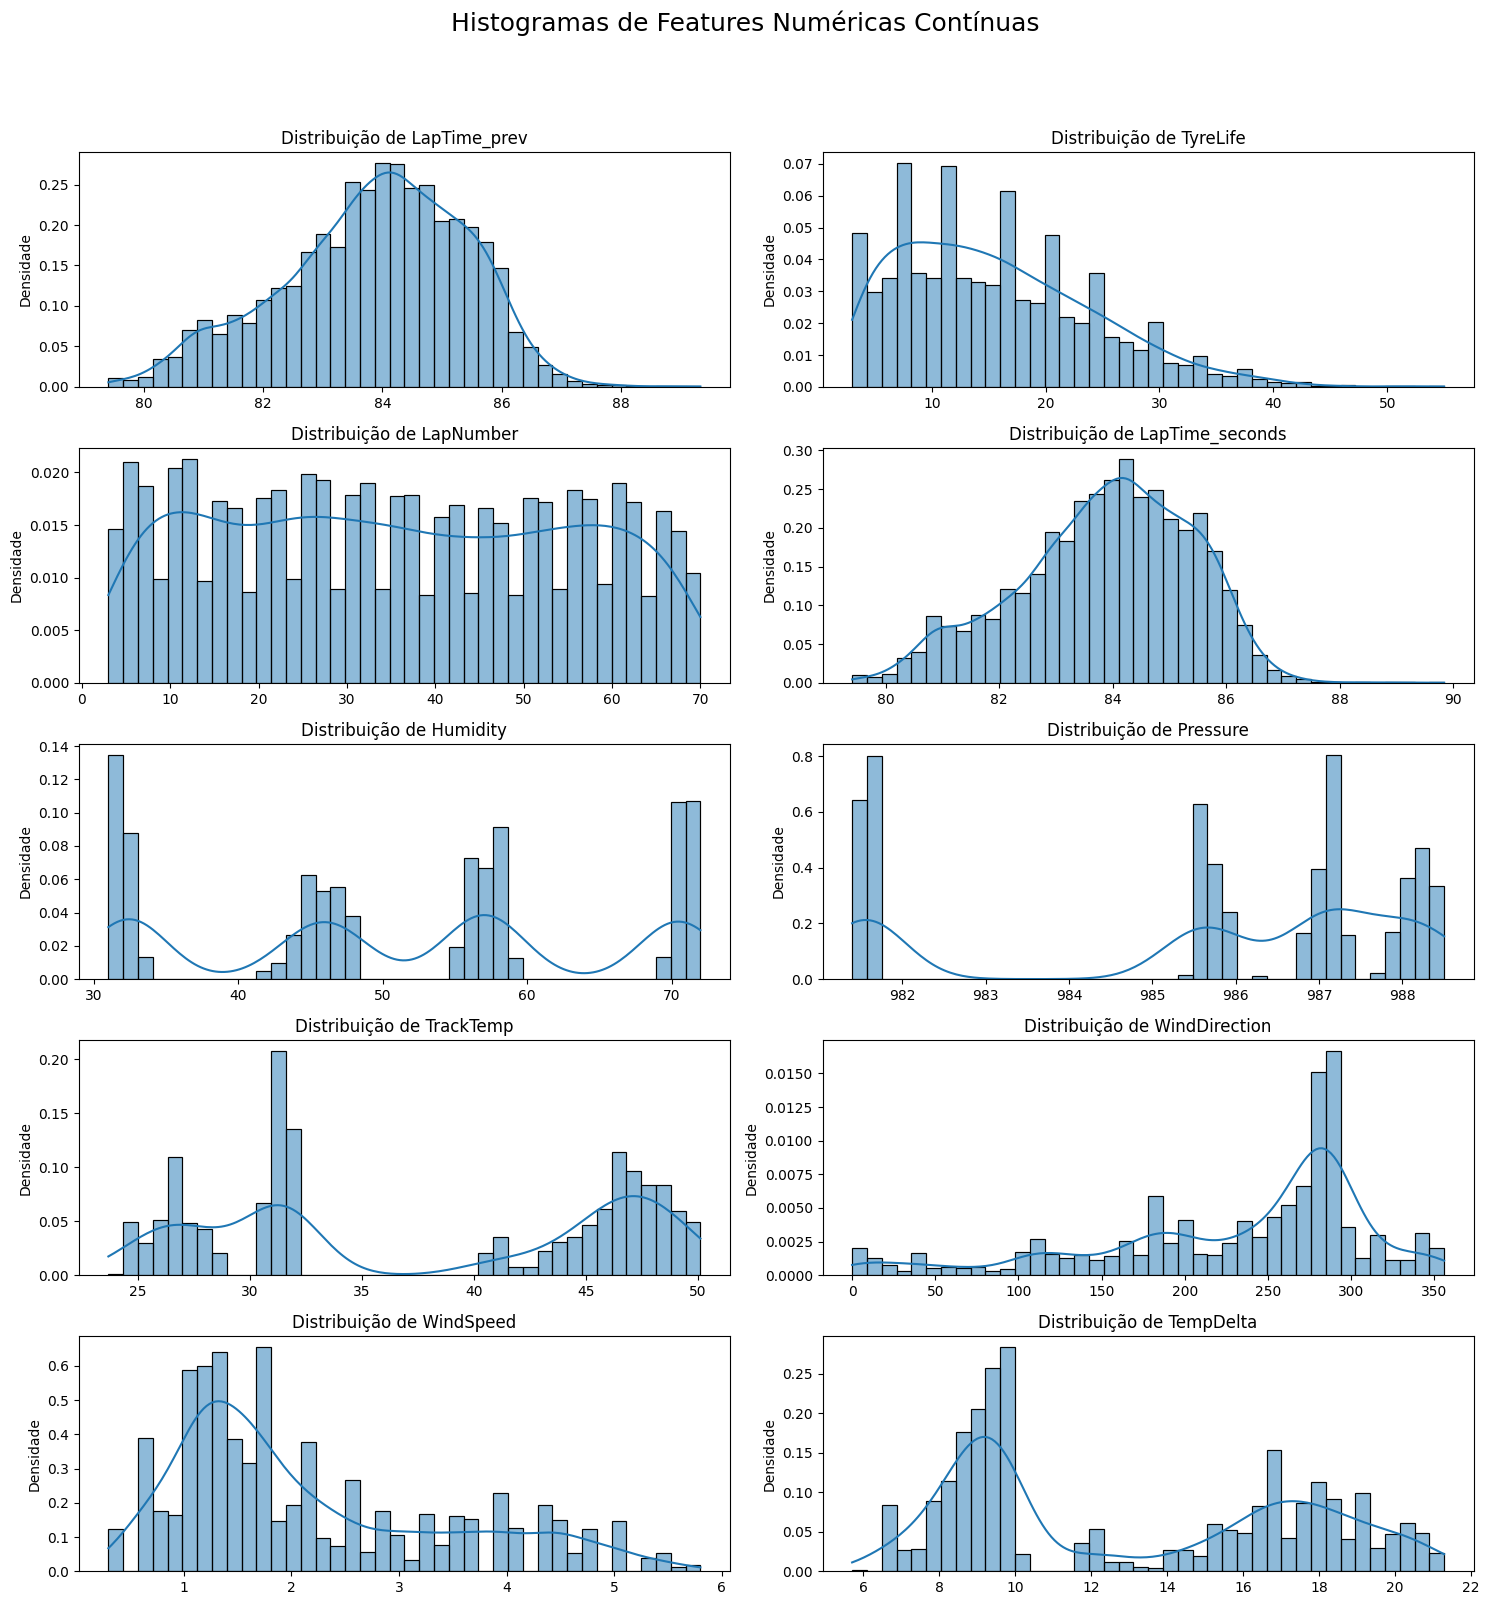

In [9]:
n_rows_cont = 5
n_cols_cont = 2
fig_cont, axes_cont = plt.subplots(n_rows_cont, n_cols_cont, figsize=(15, 16))
flat_axes_cont = axes_cont.flatten() 

continuous_cols = [
    'LapTime_prev', 'TyreLife', 'LapNumber', 'LapTime_seconds', 'Humidity', 
    'Pressure', 'TrackTemp', 'WindDirection', 'WindSpeed', 'TempDelta'
]

num_df = laps_cleaned[continuous_cols].copy()

for i, col in enumerate(continuous_cols):
    ax = flat_axes_cont[i]
    
    data_to_plot = num_df[col].dropna()
    
    if data_to_plot.empty:
        ax.set_title(f'{col} (Sem Dados)')
        ax.text(0.5, 0.5, 'Sem Dados', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
        ax.set_xticks([]); ax.set_yticks([])
    else:
        sns.histplot(data_to_plot, kde=True, ax=ax, bins=40, stat="density") 
        ax.set_title(f'Distribuição de {col}')
        ax.set_xlabel('')
        ax.set_ylabel('Densidade') 

plt.suptitle('Histogramas de Features Numéricas Contínuas', fontsize=18, y=1.03)
plt.tight_layout(rect=[0, 0.03, 1, 0.99])

### Comportamento Específico de `TyreLife` por Composto
Histogramas separados por composto de pneu revelam perfis de degradação distintos (C1 > C2 > C3 em curvatan).

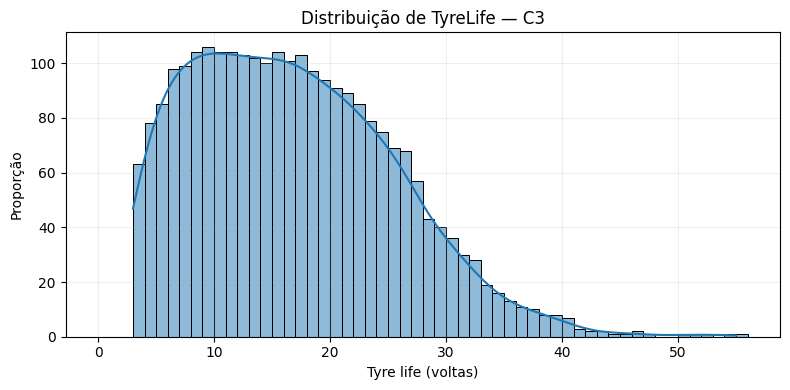

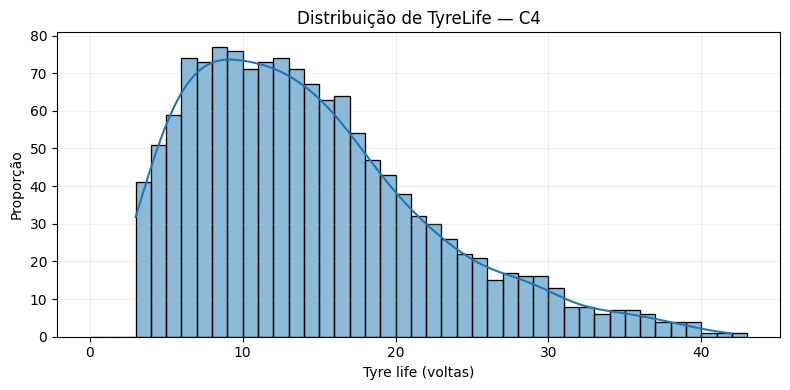

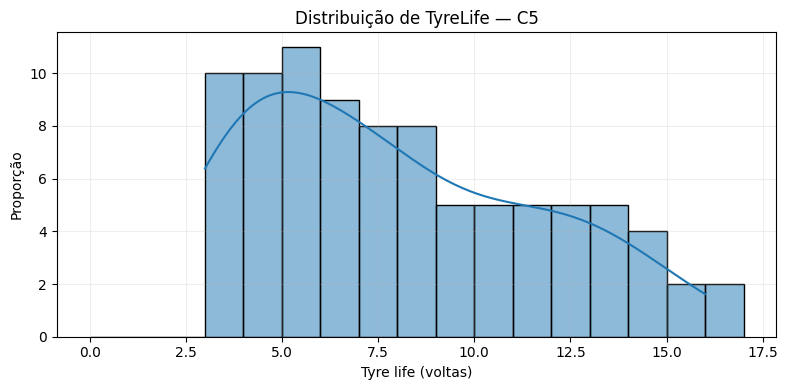

In [10]:
compounds_to_plot = ['C3','C4','C5']

for comp in compounds_to_plot:
    if 'pirelliCompound' in laps_cleaned.columns:
        subset = laps_cleaned[laps_cleaned['pirelliCompound'] == comp]
    elif 'Compound' in laps_cleaned.columns:
        subset = laps_cleaned[laps_cleaned['Compound'] == comp]
    else:
        subset = laps_cleaned[laps_cleaned.get('compound') == comp] if 'compound' in laps_cleaned.columns else laps_cleaned[[]]

    if subset.empty:
        print(f'Nenhum dado disponível para o composto {comp}. Pulando.')
        continue

    tyre_life = subset['TyreLife'].dropna()
    if tyre_life.empty:
        print(f'Nenhum TyreLife válido para {comp}. Pulando.')
        continue

    max_life = int(tyre_life.max()) if pd.api.types.is_numeric_dtype(tyre_life) else tyre_life.max()
    bins = range(0, max(2, max_life + 2)) if isinstance(max_life, int) else 10

    plt.figure(figsize=(8,4))
    sns.histplot(tyre_life, bins=bins, kde=True, color='C0', stat='count')
    plt.title(f'Distribuição de TyreLife — {comp}')
    plt.xlabel('Tyre life (voltas)')
    plt.ylabel('Proporção')
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()


### Função de Distribuição Acumulada (CDF)

Complementando os histogramas, a **CDF empírica** oferece uma leitura probabilística sem o viés de binagem (agrupamento das barras):

$$F(x) = P(X \leq x) = \frac{\text{número de observações } \leq x}{n}$$

**Uso:** Quantificar *outliers* com precisão e detectar assimetrias em cauda.

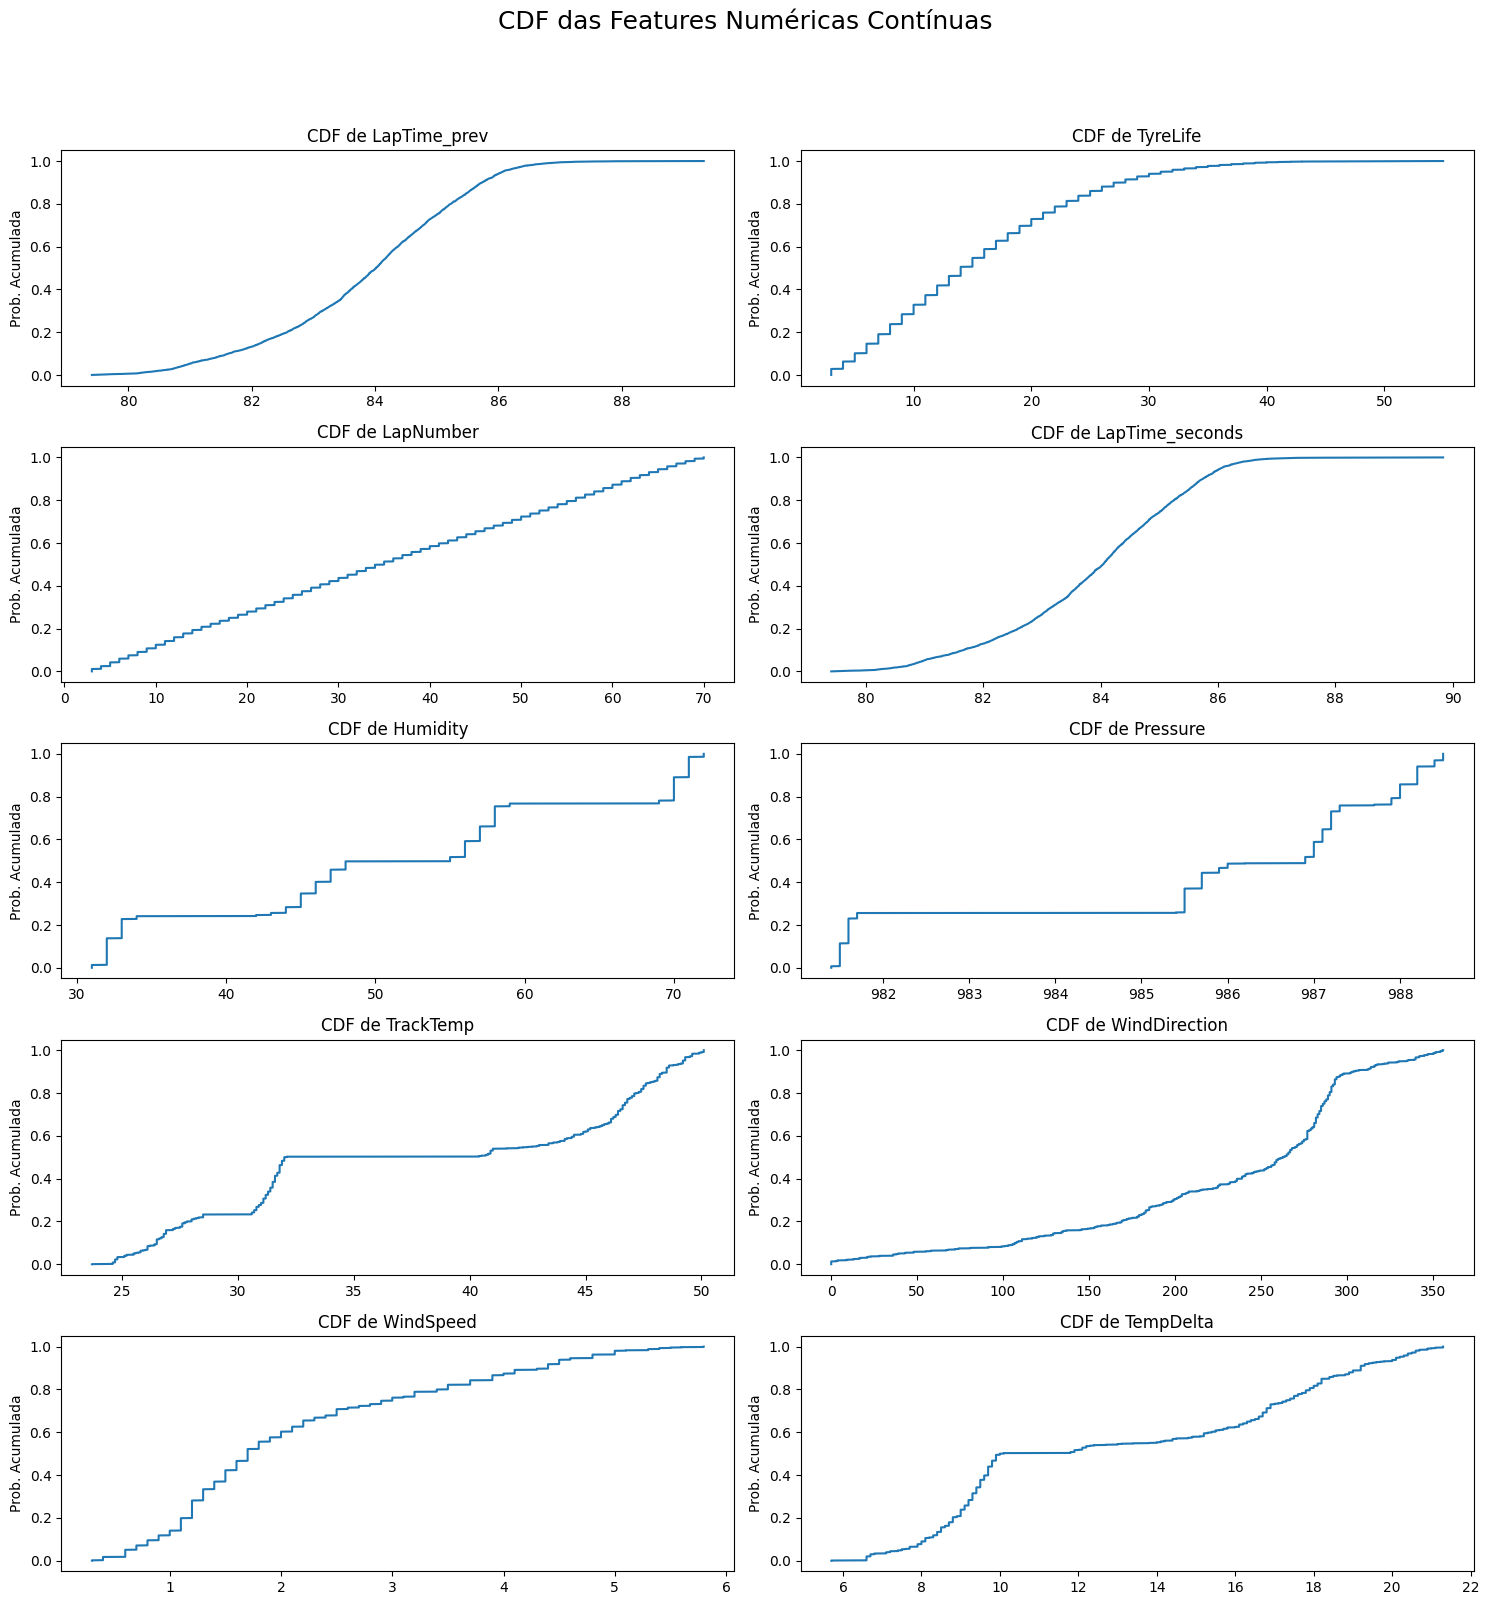

In [11]:
fig_cdf, axes_cdf = plt.subplots(n_rows_cont, n_cols_cont, figsize=(15, 16))
flat_axes_cdf = axes_cdf.flatten()


for i, col in enumerate(continuous_cols):
    ax = flat_axes_cdf[i]

    data_to_plot = num_df[col].dropna()

    if data_to_plot.empty:
        ax.set_title(f'{col} (Sem Dados)')
        ax.text(0.5, 0.5, 'Sem Dados', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
        ax.set_xticks([]); ax.set_yticks([])
    else:

        sorted_vals = np.sort(data_to_plot)
        cdf_vals = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)

        ax.plot(sorted_vals, cdf_vals)
        ax.set_title(f'CDF de {col}')
        ax.set_xlabel('')
        ax.set_ylabel('Prob. Acumulada')

plt.suptitle('CDF das Features Numéricas Contínuas', fontsize=18, y=1.03)
plt.tight_layout(rect=[0, 0.03, 1, 0.99])


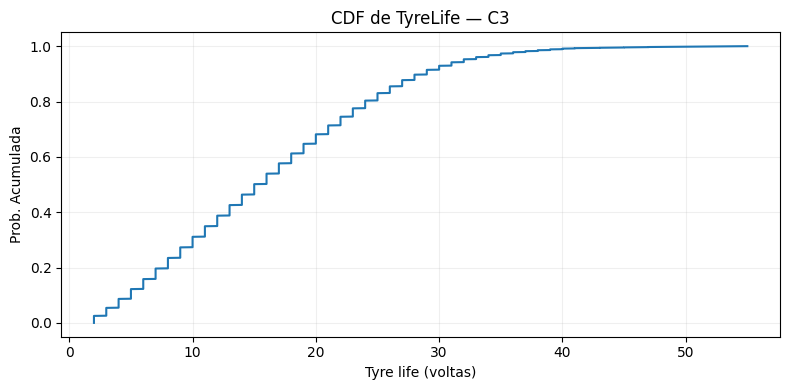

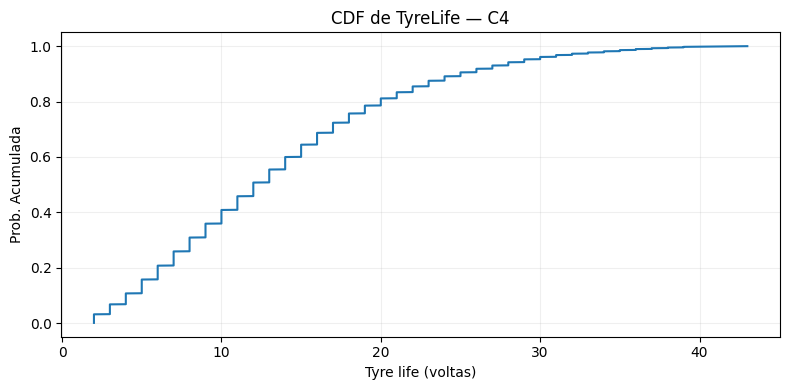

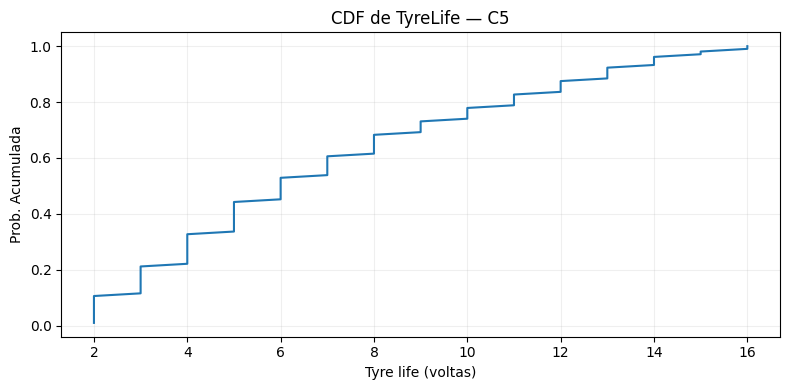

In [12]:
for comp in compounds_to_plot:
    if 'pirelliCompound' in laps_with_weather.columns:
        subset = laps_with_weather[laps_with_weather['pirelliCompound'] == comp]
    elif 'Compound' in laps_with_weather.columns:
        subset = laps_with_weather[laps_with_weather['Compound'] == comp]
    else:
        subset = laps_with_weather[laps_with_weather.get('compound') == comp] if 'compound' in laps_with_weather.columns else laps_with_weather[[]]

    if subset.empty:
        print(f'Nenhum dado disponível para o composto {comp}. Pulando.')
        continue

    tyre_life = subset['TyreLife'].dropna()
    if tyre_life.empty:
        print(f'Nenhum TyreLife válido para {comp}. Pulando.')
        continue

    sorted_vals = np.sort(tyre_life)
    cdf_vals = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)

    plt.figure(figsize=(8,4))
    plt.plot(sorted_vals, cdf_vals, color='C0')
    plt.title(f'CDF de TyreLife — {comp}')
    plt.xlabel('Tyre life (voltas)')
    plt.ylabel('Prob. Acumulada')
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()


---

## 7. Análise de Frequência - Variáveis Categóricas

### Objetivo
Identificar desequilíbrios de classe (imbalance) que afetam generalização do modelo, usando **Countplots** para quatro dimensões.

#### 1. **Pilotos (`Driver`)**
- **Interpretação:** Barras pequenas indicam pilotos com DNF (Did Not Finish) ou entrada tardia na season → menos dados de treinamento
- **Impacto:** Modelos podem overfitar em pilotos com muitos dados

#### 2. **Equipes (`Team`)**
- **Interpretação:** Distribuição revela dominância (ex: Red Bull >> Sauber)
- **Impacto:** Necessidade de técnicas de regularização para evitar viés em equipes grandes

#### 3. **Compostos de Pneus (`pirelliCompound`)**
- **Interpretação:** Meta-estratégia do circuito (ex: Bahrein: C3 >> C1)

- **Impacto:** Valida se modelo aprende performance de pneus relevantes; pneus raros têm menos exemplos- **Impacto:** Permite detecção de quebras estruturais (ex: mudança de regulamento em 2022)

- **Interpretação:** Trend temporal de regulamentações
#### 4. **Ano (`Year`)**

Gerando gráficos de frequência (Countplots) para variáveis categóricas...


C:\Users\mpoli\AppData\Local\Temp\ipykernel_18404\937487761.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data_to_plot, ax=ax, order=bar_order, palette="viridis")


C:\Users\mpoli\AppData\Local\Temp\ipykernel_18404\937487761.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
C:\Users\mpoli\AppData\Local\Temp\ipykernel_18404\937487761.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data_to_plot, ax=ax, order=bar_order, palette="viridis")
C:\Users\mpoli\AppData\Local\Temp\ipykernel_18404\937487761.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
C:\Users\mpoli\AppData\Local\Temp\ipykernel_18404\937487761.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will 

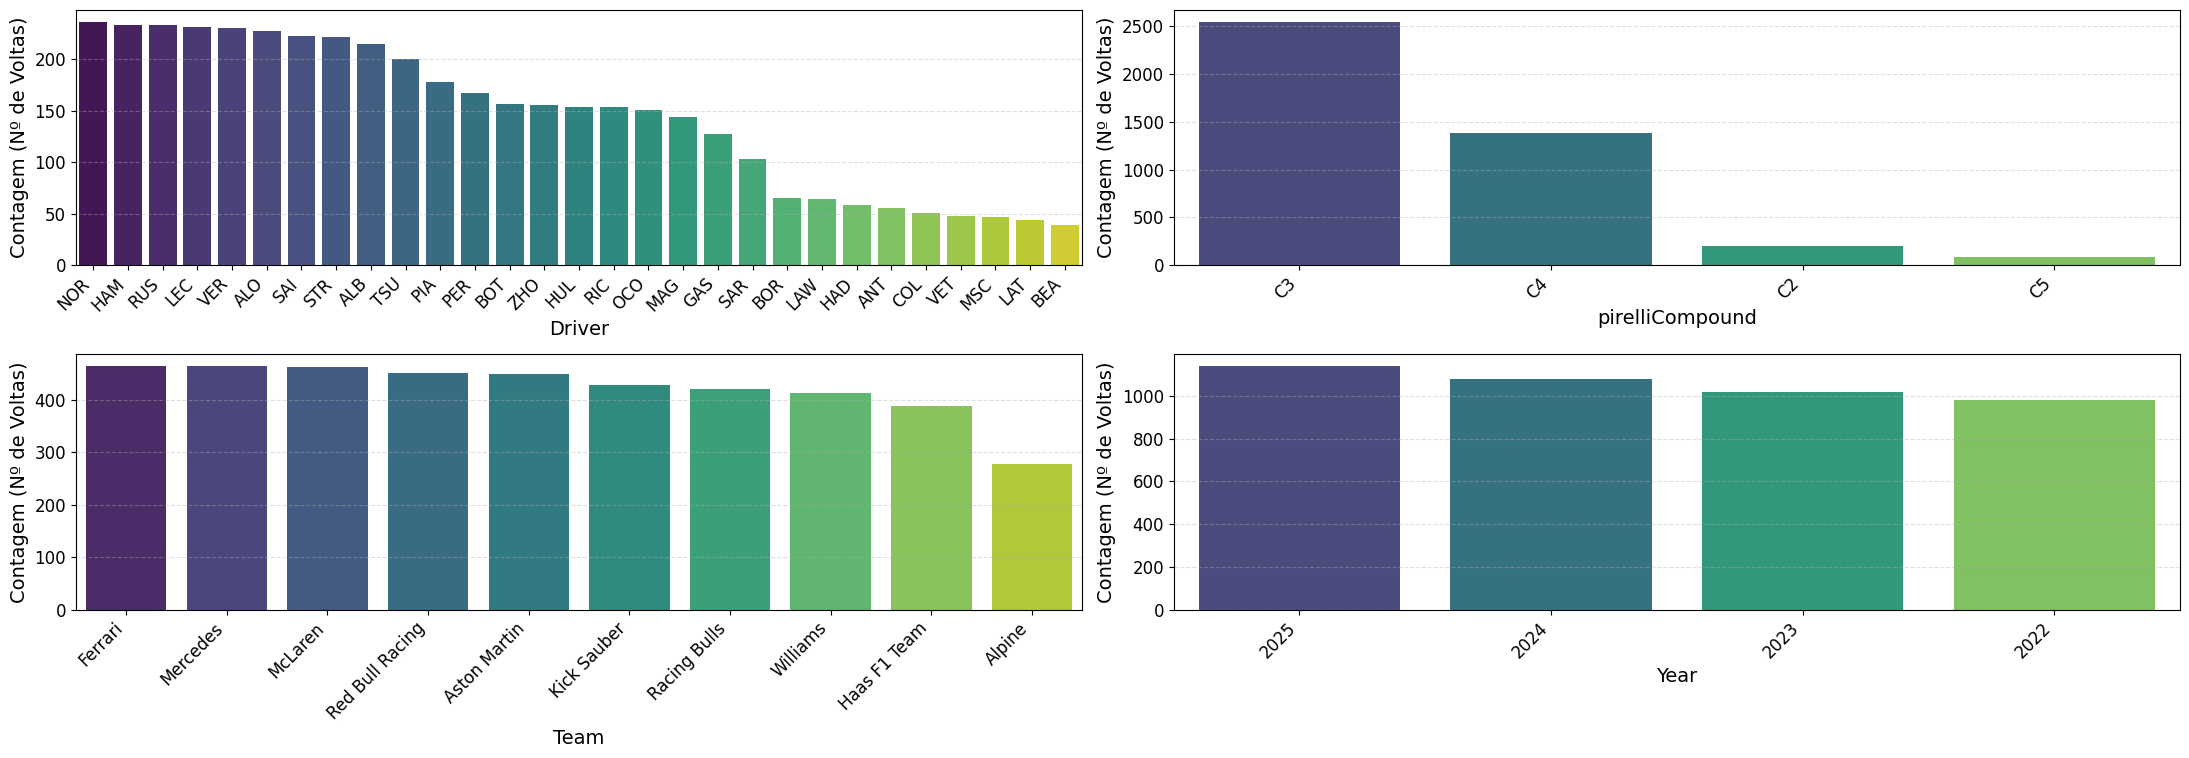

In [13]:
cat_cols = ['Driver', 'pirelliCompound', 'Team', 'Year']

print("Gerando gráficos de frequência (Countplots) para variáveis categóricas...")


n_rows_cat = 2
n_cols_cat = 2
fig_cat, axes_cat = plt.subplots(n_rows_cat, n_cols_cat, figsize=(22, 8)) 

flat_axes_cat = axes_cat.flatten()

for i, col in enumerate(cat_cols):
    ax = flat_axes_cat[i]
    
    data_to_plot = laps_cleaned[col].dropna()
    
    if data_to_plot.empty:
        ax.text(0.5, 0.5, 'Sem Dados', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
        ax.set_xticks([]); ax.set_yticks([])
    else:
        bar_order = data_to_plot.value_counts().index
        
        sns.countplot(x=data_to_plot, ax=ax, order=bar_order, palette="viridis")
        ax.set_xlabel(col, fontsize=14)
        ax.set_ylabel('Contagem (Nº de Voltas)', fontsize=14)
        ax.tick_params(axis='both', which='major', labelsize=12)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.grid(True, axis='y', linestyle='--', alpha=0.4)

plt.tight_layout(rect=[0, 0.03, 1, 0.99])

plt.show()

### Nota sobre `TrackStatus`
`TrackStatus` é um código composto que descreve a condição de pista (1=Green, 2=Yellow, 4=SafetyCar, 5=Red, etc.). Como filtramos apenas voltas com `IsAccurate=True`, quase exclusivamente temos `TrackStatus=1`. Portanto, não incluímos sua análise aqui (seria redundante pos-filtragem).


---

## 8. Diagnóstico de Dispersão e Outliers Via Boxplots

### Interpretação
Boxplots mostram **a distribuição via quartis**, permitindo visualização de outliers estatísticos:

- **Caixa = IQR:** Intervalo interquartil (50% central dos dados)
  - Caixa grande = alta variabilidade
  - Caixa pequena = consistência

- **Bigodes = [Q1-1.5×IQR, Q3+1.5×IQR]:** Limites de normalidade- **Variáveis climáticas:** Pontos isolados podem indicar falhas de sensor ou mudança climática abrupta (ex: chuva repentina)

- **Pontos isolados:** Outliers estatísticos (além de 1.5×IQR)- **`TyreLife`:** Distribuição uniforme esperada; ausência de outliers indica dados limpos

- **`LapTime_seconds`:** Pontos acima do limite superior refletem voltas lentas remanescentes (apesar do `IsAccurate`)
### Interpretações Específicas para F1

C:\Users\mpoli\AppData\Local\Temp\ipykernel_18404\1481522615.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=data_to_plot, ax=ax, palette="viridis")
C:\Users\mpoli\AppData\Local\Temp\ipykernel_18404\1481522615.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=data_to_plot, ax=ax, palette="viridis")
C:\Users\mpoli\AppData\Local\Temp\ipykernel_18404\1481522615.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=data_to_plot, ax=ax, palette="viridis")
C:\Users\mpoli\AppData\Local\Temp\ipykernel_18404\1481522615.py:18: FutureWarni

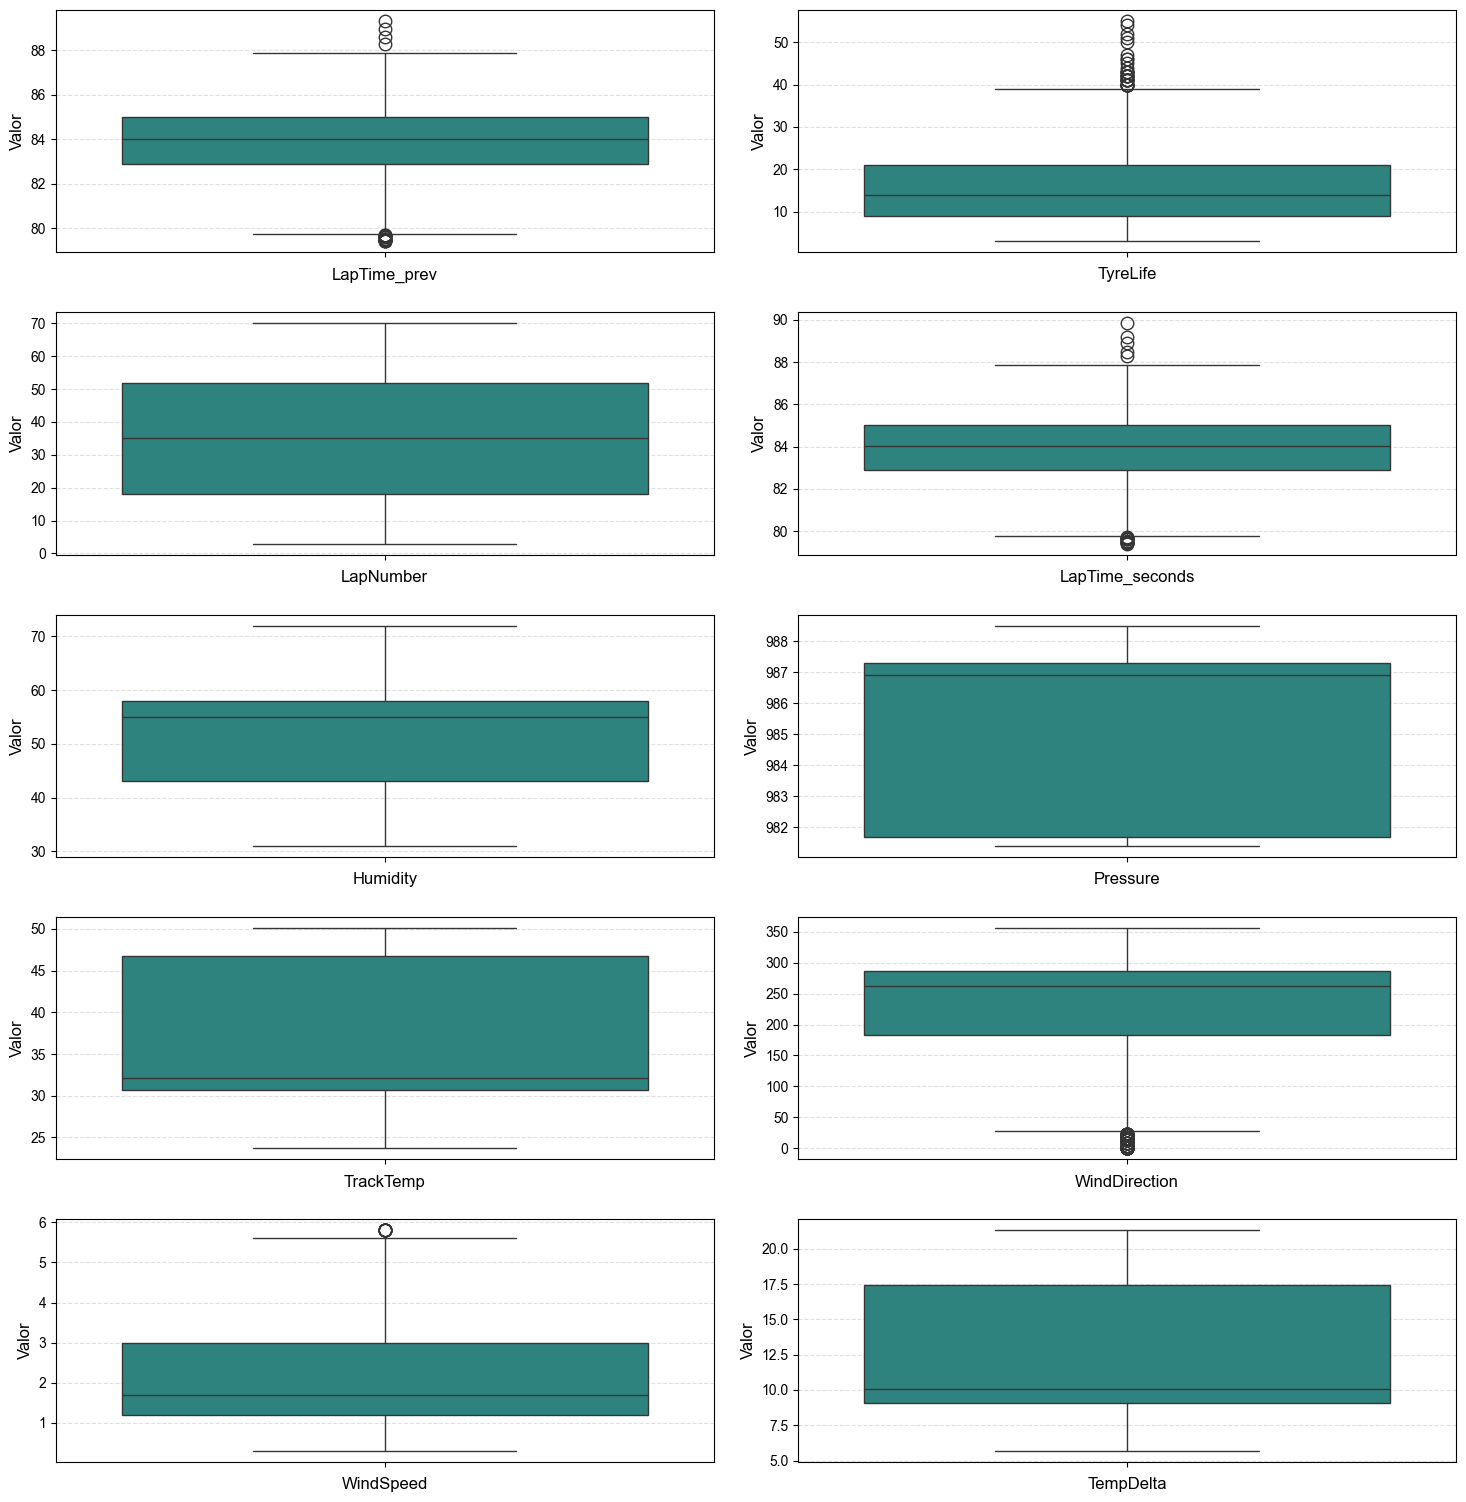

In [14]:
n_rows = 5
n_cols = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 16))
flat_axes = axes.flatten()

sns.set_style("whitegrid")
sns.set_context("talk")

for i, col in enumerate(continuous_cols):
    ax = flat_axes[i]
    
    data_to_plot = laps_cleaned[col].dropna()
    
    if data_to_plot.empty:
        ax.text(0.5, 0.5, 'Sem Dados', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
        ax.set_xticks([]); ax.set_yticks([])
    else:
        sns.boxplot(y=data_to_plot, ax=ax, palette="viridis")
        ax.set_xlabel(col, fontsize=12)
        ax.set_ylabel('Valor', fontsize=12)
        ax.grid(True, axis='y', linestyle='--', alpha=0.4)
        ax.tick_params(axis='both', which='major', labelsize=10)
            
plt.tight_layout(rect=[0, 0.03, 1, 0.99])
plt.show()

---

## 9. Estatísticas Descritivas e Momentos de Distribuição

### Métricas Calculadas

1. **Skewness (Assimetria):**
   $$\text{Skewness} = E\left[\left(\frac{X-\mu}{\sigma}\right)^3\right]$$
   - Mede desvio da simetria normal
   - **Skewness > 1:** Cauda direita (right-skewed)
   - **Skewness < -1:** Cauda esquerda (left-skewed)
   - Indica necessidade de transformação (log, box-cox)



2. **Kurtosis (Curtose):****Tabela gerada:** 10 variáveis × (min, median, max, std, skewness, kurtosis, CV)

   - Mede "peso" das caudas (propensão a outliers)

   - Alto kurtosis → caudas pesadas → outliers frequentes   - Permite comparação entre variáveis de escalas diferentes

   - Medida adimensional de dispersão relativa

3. **Coeficiente de Variação (CV):**   $$CV = \frac{\sigma}{\mu}$$

In [15]:
try:
    stats_df = laps_cleaned.describe(include='all')

    features_interesse = [
    'LapTime_prev', 'TyreLife', 'LapNumber', 'LapTime_seconds',
    'Humidity', 'Pressure', 'TrackTemp', 'WindDirection', 'WindSpeed', 'TempDelta'
    ]

    skewness = laps_cleaned.skew(numeric_only=True)

    kurtosis = laps_cleaned.kurt(numeric_only=True)

    means = laps_cleaned.mean(numeric_only=True)
    stds = laps_cleaned.std(numeric_only=True)

    cv = np.where(means == 0, np.nan, stds / means)
    
    cv_series = pd.Series(cv, index=means.index)

    stats_df = stats_df[features_interesse]

    stats_df.loc['skewness'] = skewness
    stats_df.loc['kurtosis'] = kurtosis
    stats_df.loc['CV (Coef. Var)'] = cv_series


    print("\n--- Estatísticas ---")
    display(stats_df)
    

except Exception as e:
    print(f"Ocorreu um erro ao calcular as estatísticas: {e}")
    print("Verifique se o DataFrame 'laps_with_weather' existe e não está vazio.")


--- Estatísticas ---


,LapTime_prev,TyreLife,LapNumber,LapTime_seconds,Humidity,Pressure,TrackTemp,WindDirection,WindSpeed,TempDelta
count,4213.000000,4213.000000,4213.000000,4213.000000,4213.000000,4213.000000,4213.000000,4213.000000,4213.000000,4213.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,83.859169,15.648944,35.330169,83.877545,51.355329,985.602397,37.742179,230.217422,2.166888,12.997674
std,1.539269,8.588705,19.368875,1.525488,13.744489,2.528872,8.966111,82.822008,1.276424,4.509891
min,79.409000,3.000000,3.000000,79.412000,31.000000,981.400000,23.700000,0.000000,0.300000,5.700000
25%,82.880000,9.000000,18.000000,82.908000,43.000000,981.700000,30.700000,183.000000,1.200000,9.100000
50%,84.015000,14.000000,35.000000,84.042000,55.000000,986.900000,32.100000,263.000000,1.700000,10.100000
75%,85.005000,21.000000,52.000000,85.029000,58.000000,987.300000,46.700000,287.000000,3.000000,17.400000


---

## 10. Diagnóstico de Assimetria e Transformação de Variáveis

### Por Quê Normalização?
Modelos lineares (OLS, Ridge) e árvores (XGBoost) performam melhor com:
- Resíduos distribuídos ~Normal
- Variáveis preditoras com distribuição mais simétrica possível
- Sem outliers extremos distorcionando aprendizado

### Critério de Detecção
**Threshold:** $|\text{Skewness}| > 1.0$ (assimetria moderada a severa)

#### Categorias Identificadas:

1. **Right Skewed (Skewness > 1):**- **Efeito:** Comprime cauda direita, traz distribuição próxima à normal

   - Muitos valores baixos, cauda longa à direita- **Vantagem:** Define-se em x=0 (evita $\log(0) = -\infty$)

   - **Ação:** Aplicar transformação logarítmica $\log(1 + x)$Transformação utilizada: $\text{log1p}(x) = \log(1 + x)$

### Implementação: Log-Transformation

2. **Left Skewed (Skewness < -1):**

   - Concentração em valores altos, cauda curta   - **Ação:** Transformação box-cox ou reflexão

In [16]:
# Quais features da tabela têm:
# - skewness > 1
# - skewness < -1
# stats_df já foi calculado anteriormente
skewed_features = {
    'right_skewed': [],
    'left_skewed': []
}

for feature in stats_df.columns:
    skewness_value = stats_df.at['skewness', feature]
    if pd.notna(skewness_value):
        if skewness_value > 1:
            skewed_features['right_skewed'].append(feature)
        elif skewness_value < -1:
            skewed_features['left_skewed'].append(feature)

print("\n--- Features com Skewness Significativo ---")
print("Right Skewed (skewness > 1):", skewed_features['right_skewed'])
print("Left Skewed (skewness < -1):", skewed_features['left_skewed'])



--- Features com Skewness Significativo ---
Right Skewed (skewness > 1): []
Left Skewed (skewness < -1): ['WindDirection']


---

## 11. Análise Estratégica - Matriz de Transição de Pneus (Markov)

### Contexto: "Meta-Game" da Corrida
Em F1, a estratégia de pneus define o resultado. Matriz de transição revela padrões de mudança de composto entre stints.

### Pergunta Central
$$P(\text{Stint}_{i+1} \text{ usa composto Y} | \text{Stint}_i \text{ usa composto X})$$

### Construção

1. **Redução para Stints únicos:** Uma linha por (Year, Driver, Stint, Composto)- **Distribuição simétrica** → padrão estratégico estável entre anos

2. **Shift temporal:** Alinha `From_Compound` (stint i) com `To_Compound` (stint i+1)- **Transições C3→C3 raras** → estratégia conservadora é improvável

3. **Contagem:** Cria matriz de frequências da transição- **Alta degradação** → transições C3→C2 ou C3→C1 esperadas (mudar para pneu mais duro)

### Interpretação Bahrein

Analisando transições de compostos entre stints...

--- Matriz de Contagem de Transição de Stints ---


To_Compound,C2,C3,C4,C5
From_Compound,,,,
C2,0,2,2,0
C3,9,33,26,2
C4,0,52,6,1
C5,0,7,4,0



Gerando heatmap da matriz de transição...


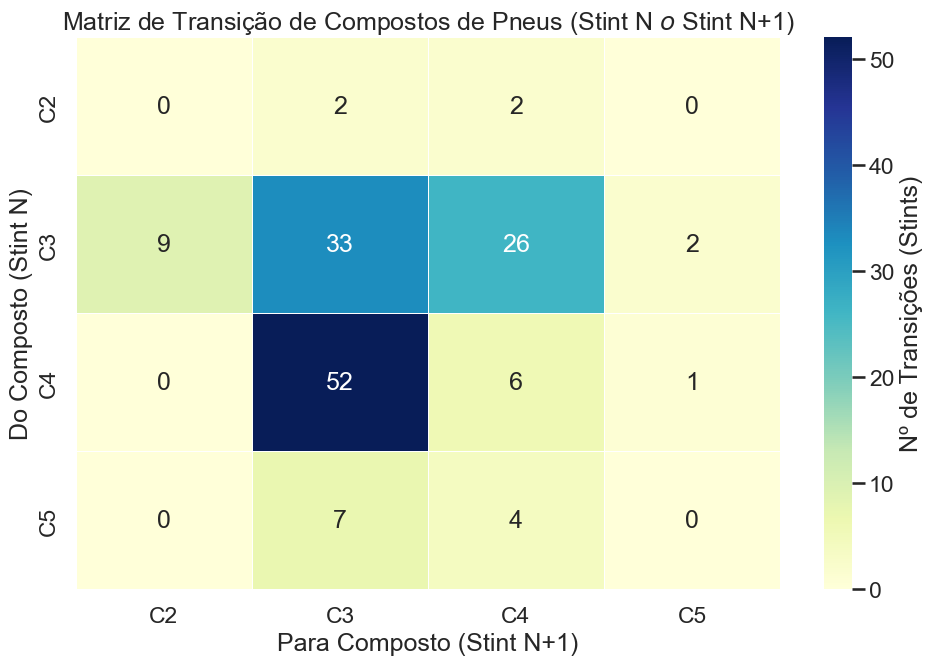

In [17]:
print("Analisando transições de compostos entre stints...")

try:

    stint_df = laps_cleaned[
        ['Year', 'Driver', 'Stint', 'pirelliCompound']
    ].drop_duplicates()
    
    stint_df = stint_df.sort_values(by=['Year', 'Driver', 'Stint'])

    stint_df['To_Compound'] = stint_df.groupby(['Year', 'Driver'])['pirelliCompound'].shift(-1)
    
    stint_df = stint_df.rename(columns={'pirelliCompound': 'From_Compound'})
    
    transitions_df = stint_df.dropna(subset=['To_Compound'])

    if transitions_df.empty:
        print("Não foi possível encontrar dados de transição (múltiplos stints) no DataFrame.")
    else:
        transition_matrix = pd.crosstab(
            transitions_df['From_Compound'], 
            transitions_df['To_Compound']
        )

        print("\n--- Matriz de Contagem de Transição de Stints ---")
        display(transition_matrix)

        print("\nGerando heatmap da matriz de transição...")
        plt.figure(figsize=(10, 7))
        
        ax = sns.heatmap(
            transition_matrix, 
            annot=True, 
            fmt="d",  
            cmap="YlGnBu", 
            linewidths=.5,
            cbar_kws={'label': 'Nº de Transições (Stints)'}
        )
        
        ax.set_title('Matriz de Transição de Compostos de Pneus (Stint N $\to$ Stint N+1)')
        ax.set_xlabel('Para Composto (Stint N+1)')
        ax.set_ylabel('Do Composto (Stint N)')
        plt.tight_layout()
        plt.show()

except NameError:
    print("Erro: O DataFrame 'laps_with_weather_filtered' não foi encontrado.")
    print("Por favor, execute a célula anterior que define este DataFrame.")
except Exception as e:
    print(f"Ocorreu um erro inesperado: {e}")

### 12. Aplicação de Transformações - Log-Transformation

**Fórmula:**
$$x' = \log(1 + x) = \text{log1p}(x)$$

**Justificativa:**
- Define-se em x=0 (evita singularidade de log puro)
- Compress a cauda direita, puxando outliers para perto
- Efeito: distribuição mais próxima da Gaussiana


**Validação visual:** Histogramas lado a lado- **Métrica:** Skewness deve reduzir significativamente

- **Vermelho (Original):** Distribuição assimétrica original- **Verde (Transformado):** Distribuição mais simétrica pós-transformação

In [18]:
right_skewed_cols = skewed_features['right_skewed']

for col in right_skewed_cols:
    if col in laps_cleaned.columns:
        laps_cleaned[f'{col}_log'] = np.log1p(laps_cleaned[col])

for col in right_skewed_cols:
    if col in laps_cleaned.columns:
        fig, ax = plt.subplots(1, 2, figsize=(12, 4))
        
        # Original
        sns.histplot(laps_cleaned[col], kde=True, ax=ax[0], color='red')
        ax[0].set_title(f'{col} - Original (Skew: {laps_cleaned[col].skew():.2f})')
        
        # Transformado
        sns.histplot(laps_cleaned[f'{col}_log'], kde=True, ax=ax[1], color='green')
        ax[1].set_title(f'{col}_log - Transformado (Skew: {laps_cleaned[f"{col}_log"].skew():.2f})')
        
        plt.tight_layout()
        plt.show()

---

## 13. Engenharia de Features: Captura de Não-Linearidades (RBF)

### Problema Físico
Variáveis climáticas (ex: `TrackTemp`) não têm relação linear com performance. Existe uma **"Janela de Operação Ótima"** para pneumáticos:

| Regime | Temperatura | Performance | Efeito |
|--------|-------------|-------------|--------|
| Frio | Baixa | Pior | Pneu não aquece, falta grip |
| **Ótimo** | **Mediana** | **Melhor** | Pneu no pico de aderência |
| Quente | Alta | Pior | Blistering, degradação acelerada |

### Solução: Transformação RBF
Aplicamos uma **Função de Base Radial (RBF)** centrada na **mediana histórica**:

$$\text{RBF}(x) = e^{-\gamma (x - \mu)^2}$$



Onde:

- $\mu$ = Mediana da variável (estimativa de "temperatura ideal")6 variáveis climáticas: `TrackTemp, Humidity, Pressure, WindSpeed, WindDirection, TempDelta`

- $\gamma = 0.1$ (escala: quanto mais distante de μ, menor o valor)### Variáveis Processadas

- **Efeito:** Máximo em μ (valor 1), decai para 0 em extremos

Aplicando Transformação RBF (Gamma=0.1) usando a MEDIANA como referência...
Coluna 'TrackTemp': Mediana = 32.10
Coluna 'Humidity': Mediana = 55.00
Coluna 'Pressure': Mediana = 986.90
Coluna 'WindSpeed': Mediana = 1.70
Coluna 'WindDirection': Mediana = 263.00
Coluna 'TempDelta': Mediana = 10.10


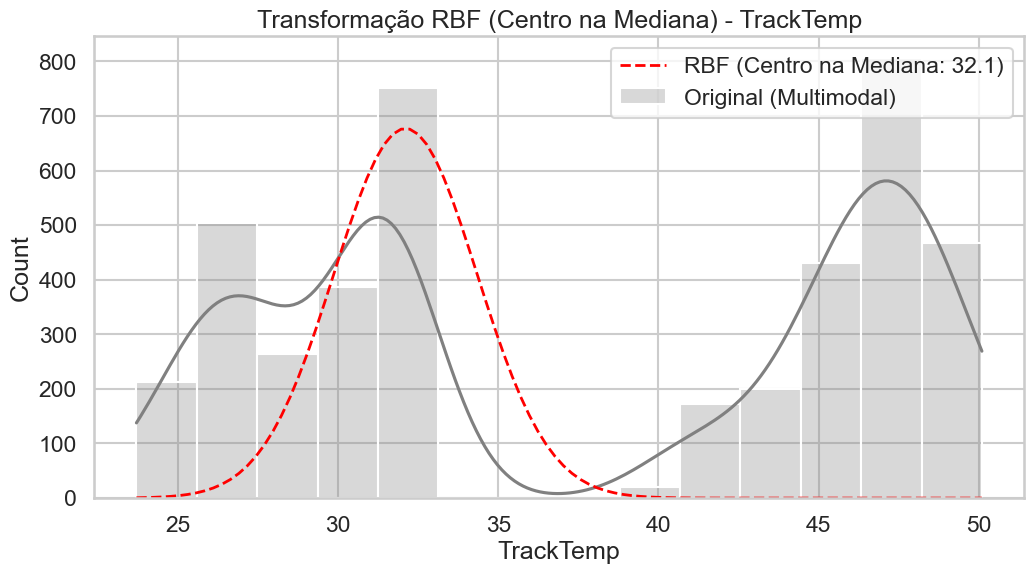


Novas Features Criadas: ['TrackTemp_RBF_Median', 'Humidity_RBF_Median', 'Pressure_RBF_Median', 'WindSpeed_RBF_Median', 'WindDirection_RBF_Median', 'TempDelta_RBF_Median']


In [19]:
weather_cols = ['TrackTemp', 'Humidity', 'Pressure', 'WindSpeed', 'WindDirection', 'TempDelta']
gamma_value = 0.1

print(f"Aplicando Transformação RBF (Gamma={gamma_value}) usando a MEDIANA como referência...")

for col in weather_cols:
    if col in laps_cleaned.columns:
        median_val = laps_cleaned[col].median()
        
        print(f"Coluna '{col}': Mediana = {median_val:.2f}")
    
        col_name = f"{col}_RBF_Median"
        
        squared_dist = (laps_cleaned[col] - median_val) ** 2
        laps_cleaned[col_name] = np.exp(-gamma_value * squared_dist)
        
        laps_cleaned[col_name] = laps_cleaned[col_name].fillna(0)

col_exemplo = 'TrackTemp'
if col_exemplo in weather_cols:
    col_transformed = f"{col_exemplo}_RBF_Median"
    median_exemplo = laps_cleaned[col_exemplo].median()
    
    plt.figure(figsize=(12, 6))
    ax1 = plt.gca()
    
    sns.histplot(laps_cleaned[col_exemplo], kde=True, ax=ax1, color='gray', alpha=0.3, label='Original (Multimodal)')
    
    x_range = np.linspace(laps_cleaned[col_exemplo].min(), laps_cleaned[col_exemplo].max(), 100)
    y_rbf = np.exp(-gamma_value * (x_range - median_exemplo)**2)
    
    y_max_hist = ax1.get_ylim()[1]
    plt.plot(x_range, y_rbf * y_max_hist * 0.8, color='red', linewidth=2, linestyle='--', label=f'RBF (Centro na Mediana: {median_exemplo:.1f})')

    plt.title(f'Transformação RBF (Centro na Mediana) - {col_exemplo}')
    plt.legend()
    plt.show()

new_features = [c for c in laps_cleaned.columns if '_RBF_Median' in c]
print(f"\nNovas Features Criadas: {new_features}")

---

## 14. Análise Multivariada - Matriz de Correlação de Pearson

### Objetivo
Quantificar relações lineares entre preditores e target (`LapTime_seconds`) para:
1. Validar intuições físicas
2. Detectar multicolinearidade (variáveis muito correlacionadas entre si)
3. Informar seleção de features para o modelo

### Conjunto de Variáveis
- **Numéricas:** 10 originais + transformações (log, RBF) = ~16 features
- **Categóricas (One-Hot):** Driver, Team, Compound, Year = ~30 dummies
- **Total: ~46 variáveis** → Matriz 46×46

Correlação > 0.9 entre preditores → **Redundância** → Remover uma das variáveis

### Leituras Esperadas### Avisos Multicolinearidade



| Variável | Correlação Esperada | Interpretação || `Humidity_RBF_Median` | -0.05 a +0.15 | Efeito climático menor |

|----------|-------------------|---------------|| `TrackTemp_RBF_Median` | +0.10 a +0.25 | Desvio do ideal piora performance |

| `LapTime_prev` | +0.85 a +0.95 | Inércia temporal forte || `Team_Sauber` | +0.30 a +0.50 | Equipe inferior aumenta tempo |

| `TyreLife` | +0.15 a +0.35 | Degradação: pneu velho = volta lenta || `Team_RedBull` | -0.40 a -0.60 | Equipe superior reduz tempo |

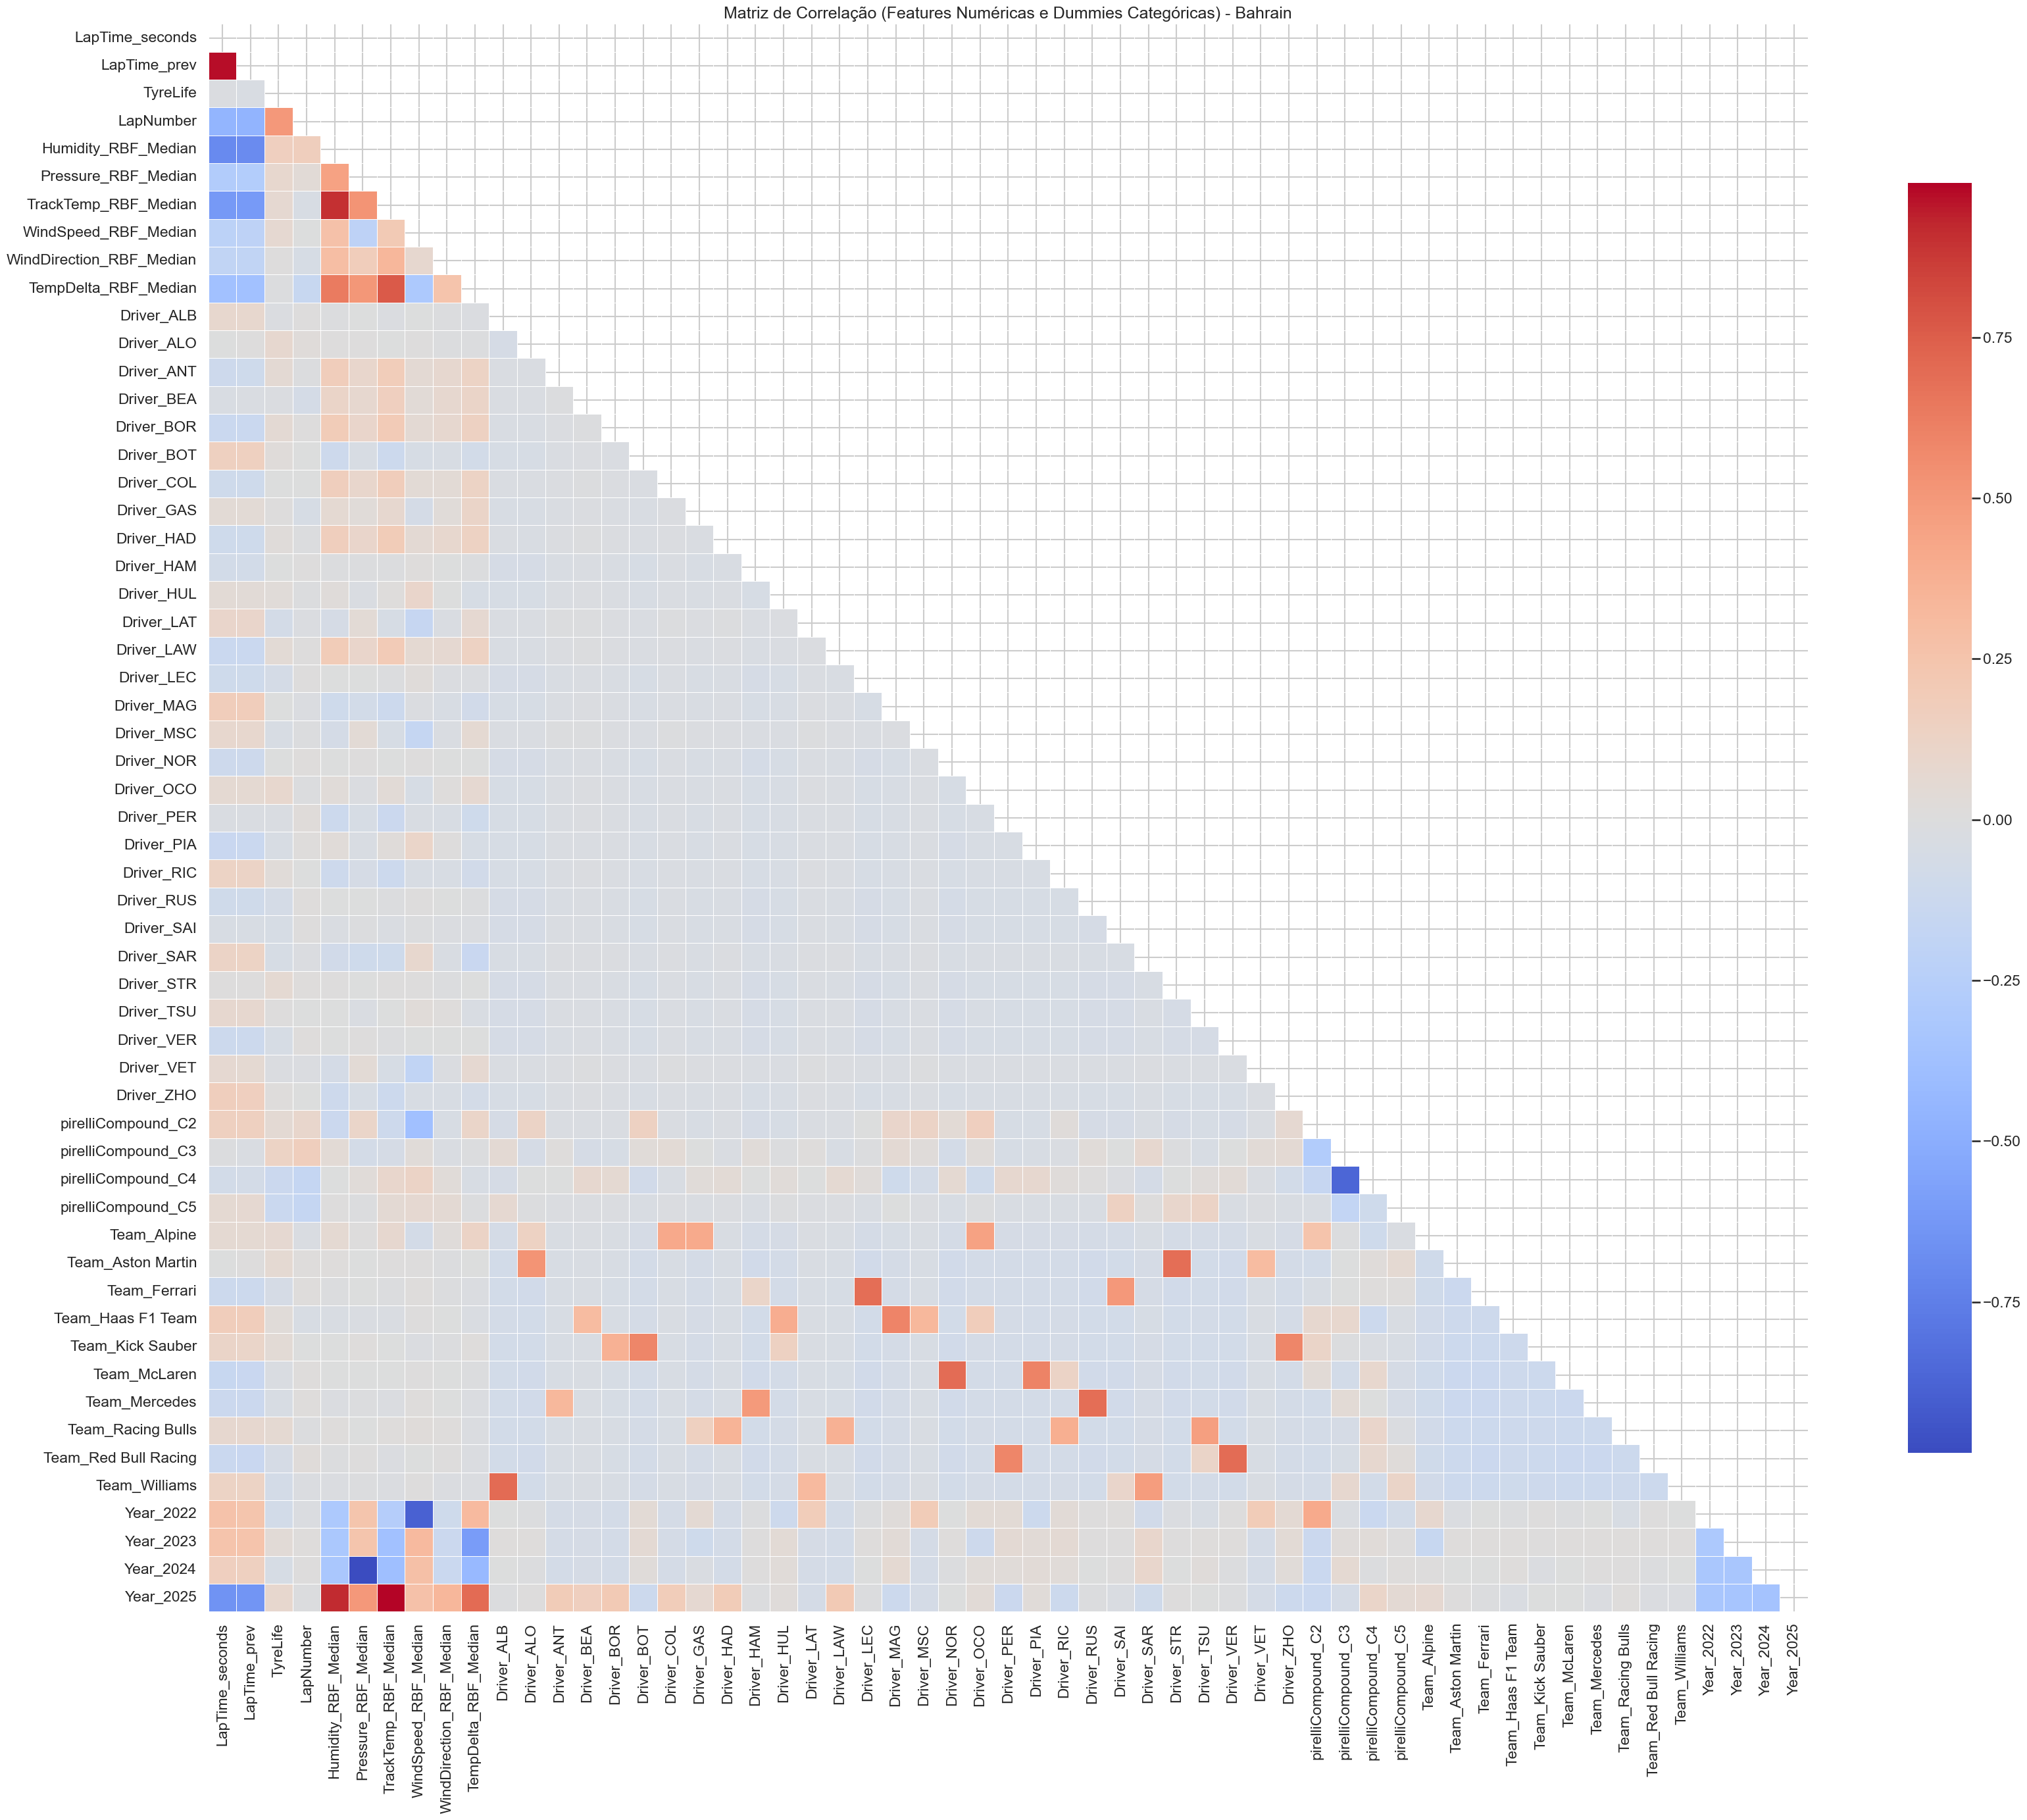

In [20]:
num_cols = ['LapTime_seconds', 'LapTime_prev', 'TyreLife', 'LapNumber',
        'Humidity_RBF_Median','Pressure_RBF_Median', 'TrackTemp_RBF_Median', 'WindSpeed_RBF_Median', 'WindDirection_RBF_Median', 
        'TempDelta_RBF_Median']

cat_cols = ['Driver', 'pirelliCompound', 'Team', 'Year']
cat_dummies = pd.get_dummies(laps_cleaned[cat_cols].astype(str), prefix=cat_cols)

num_df = laps_cleaned[num_cols].copy()
corr_df_full = pd.concat([num_df, cat_dummies], axis=1)

corr_df_clean = corr_df_full.dropna()
corr_matrix = corr_df_clean.corr()
# Mostrar a triangular inferior apenas
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(34, 28))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=
            0, annot=False, fmt=".2f", 
            cbar_kws={"shrink": .8}, linewidths=.5)
plt.title('Matriz de Correlação (Features Numéricas e Dummies Categóricas) - Bahrain')
plt.tight_layout()
plt.show()


---

## 15. Redução de Dimensionalidade (PCA)

### Problema
**"Maldição da Dimensionalidade":** 46 features → modelo requer exponencialmente mais dados para treinar sem overfitting. Além disso, multicolinearidade excessiva causa instabilidade numérica.

### Solução: PCA
**Principal Component Analysis** identifica **direções ortogonais de máxima variância**, permitindo redução de 46 → k dimensões sem perda significativa de informação.

### Pré-processamento (Crítico)
1. **Imputação:** PCA requer dados completos (sem NaN)
   - Estratégia: Preencher com **média da coluna**
2. **Padronização:** PCA é sensível à escala

   - Z-Score: $x' = \frac{x - \mu}{\sigma}$ → Média 0, Desvio 1  - Se N₉₅% ≈ 46 → Baixa redundância (manter features originais)

   - Garante que `Pressure` (~1000) não domine `WindSpeed` (~10)  - Se N₉₅% << 46 → Alta redundância (compressão possível)

- **Insights:** 

### Interpretação: Scree Plot- **Linha Vermelha (Acumulada):** Onde cruza a verde = $N_{95\%}$ (PCs necessários)

**Gráfico:** "Variância Explicada Acumulada" (%) vs. "Número de Componentes"- **Linha Verde (95%):** Threshold de retenção de informação


Iniciando preparação de dados para PCA
Dataset pronto para ML. Shape: (4213, 57)

--- Executando PCA ---
[1.00868673e-01 5.66655761e-02 4.23565905e-02 4.08284923e-02
 3.91894835e-02 3.77574240e-02 3.73991069e-02 3.68443421e-02
 3.62343885e-02 3.57268721e-02 3.45101568e-02 3.36301871e-02
 2.94323860e-02 2.52830861e-02 2.15668533e-02 1.96072144e-02
 1.90714583e-02 1.85064848e-02 1.84088962e-02 1.83663859e-02
 1.83189536e-02 1.82832008e-02 1.81748033e-02 1.81491806e-02
 1.80142584e-02 1.79586043e-02 1.78811892e-02 1.78415837e-02
 1.78082935e-02 1.76345198e-02 1.71838548e-02 1.58017447e-02
 1.49000991e-02 1.39748984e-02 1.25205862e-02 1.19619340e-02
 9.51628761e-03 4.51358392e-03 2.83222403e-03 2.72573383e-03
 2.36852745e-03 2.16087720e-03 1.73884073e-03 1.56018292e-03
 1.24768905e-03 7.78954566e-04 6.55699069e-04 4.71411817e-04
 4.48558841e-04 1.85856773e-04 1.06156669e-04 2.76538257e-05
 2.20034045e-17 8.80779794e-18 7.82901320e-18 8.67733969e-19
 0.00000000e+00]


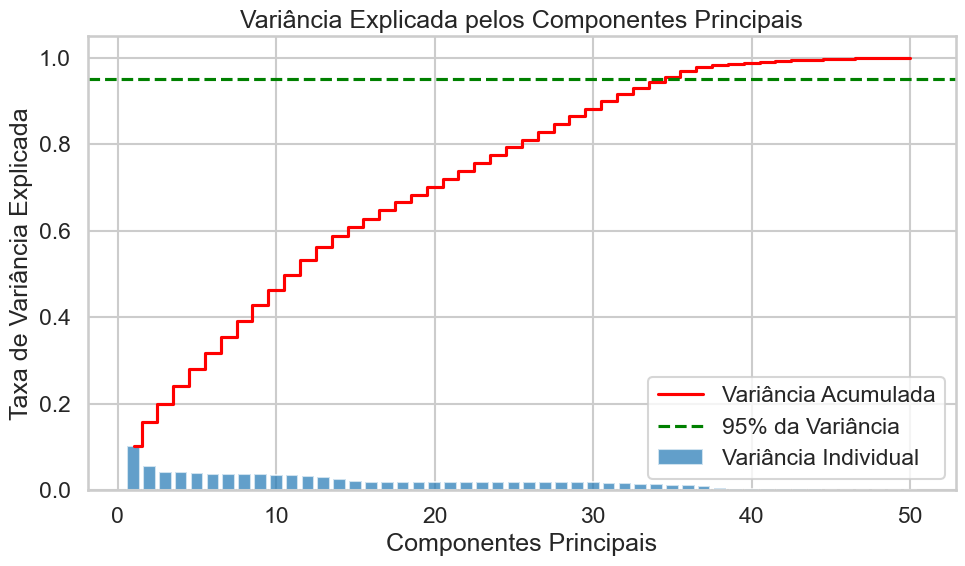

Número de Componentes para 95% da Variância: 35


In [21]:
try:
    print("Iniciando preparação de dados para PCA")
    
    ml_df_full = pd.concat([num_df, cat_dummies], axis=1)

    imputer_num = SimpleImputer(strategy='mean')
    ml_df_imputed_num = imputer_num.fit_transform(ml_df_full[num_cols])
    num_df_imputed = pd.DataFrame(ml_df_imputed_num, columns=num_cols, index=ml_df_full.index)
    ml_df_imputed_analysis = pd.concat([num_df_imputed, cat_dummies], axis=1)
    
    scaler = StandardScaler()
    ml_df_scaled = scaler.fit_transform(ml_df_imputed_analysis)
    
    print(f"Dataset pronto para ML. Shape: {ml_df_scaled.shape}")

    print("\n--- Executando PCA ---")
    pca = PCA()
    pca.fit(ml_df_scaled)
    
    explained_variance_ratio = pca.explained_variance_ratio_
    print(explained_variance_ratio)
    cumulative_variance = np.cumsum(explained_variance_ratio)

    plt.figure(figsize=(10, 6))
    num_components_to_plot = min(50, len(cumulative_variance))
    plt.bar(range(1, num_components_to_plot + 1), explained_variance_ratio[:num_components_to_plot], alpha=0.7, align='center', label='Variância Individual')
    plt.step(range(1, num_components_to_plot + 1), cumulative_variance[:num_components_to_plot], where='mid', label='Variância Acumulada', color='red')
    plt.axhline(y=0.95, color='g', linestyle='--', label='95% da Variância')
    plt.ylabel('Taxa de Variância Explicada'); plt.xlabel('Componentes Principais')
    plt.title('Variância Explicada pelos Componentes Principais'); plt.legend(loc='best')
    plt.grid(True); plt.tight_layout()
    plt.show()

    n_components_95_idx = np.where(cumulative_variance >= 0.95)[0]
    if n_components_95_idx.size > 0:
        n_components_95 = n_components_95_idx[0] + 1
    else:
        n_components_95 = len(cumulative_variance)
        
    print(f"Número de Componentes para 95% da Variância: {n_components_95}")




except NameError as e:
    print(f"ERRO: DataFrame 'laps_with_weather' não foi encontrado ({e}).")
    print("Por favor, execute a célula que carrega e processa os dados de UMA corrida primeiro (a que cria 'laps_with_weather').")
except Exception as e:
    print(f"Ocorreu um erro inesperado: {e}")

In [22]:
def plot_pca_loadings_subset_3d(pca, feature_list, full_feature_list, title):

    loadings = pca.components_.T
    pc1 = loadings[:, 0]
    pc2 = loadings[:, 1]
    pc3 = loadings[:, 2]

    idx = [full_feature_list.get_loc(feat) for feat in feature_list]

    fig = go.Figure()

    fig.add_trace(go.Scatter3d(
        x=pc1[idx],
        y=pc2[idx],
        z=pc3[idx],
        mode='markers+text',
        text=[full_feature_list[i] for i in idx],
        textposition="top center",
        marker=dict(
            size=6,
            line=dict(width=1, color='black')
        )
    ))

    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title="PC1",
            yaxis_title="PC2",
            zaxis_title="PC3",
        ),
        width=800,
        height=700
    )

    fig.show()

feature_names = ml_df_imputed_analysis.columns

lap_tyres_features = [
    'LapTime_seconds', 'LapTime_prev', 'TyreLife', 'LapNumber', 'pirelliCompound_C5', 'pirelliCompound_C4',
    'pirelliCompound_C3','pirelliCompound_C2']

plot_pca_loadings_subset_3d(
    pca,
    lap_tyres_features,
    feature_names,
    title="Loadings PCA — Variáveis Tempo de Volta e Pneus"
)

weather_features = [
    'Humidity_RBF_Median', 'Pressure_RBF_Median', 'WindSpeed_RBF_Median', 'TrackTemp_RBF_Median', 'TempDelta_RBF_Median', 'WindDirection_RBF_Median'
]

plot_pca_loadings_subset_3d(
    pca,
    weather_features,
    feature_names,
    title="Loadings PCA — Clima - Bahrein"
)

team_features = [col for col in feature_names if col.startswith('Team_')]
plot_pca_loadings_subset_3d(
    pca,
    team_features,
    feature_names,
    title="Loadings PCA — Equipes - Bahrein"
)

# Pegar todos o sufixos Driver_
driver_features = [col for col in feature_names if col.startswith('Driver_')]
plot_pca_loadings_subset_3d(
    pca,
    driver_features,
    feature_names,
    title="Loadings PCA — Pilotos - Bahrein"
)

year_features = [col for col in feature_names if col.startswith('Year_')]
plot_pca_loadings_subset_3d(
    pca,
    year_features,
    feature_names,
    title="Loadings PCA — Anos - Bahrein"
)



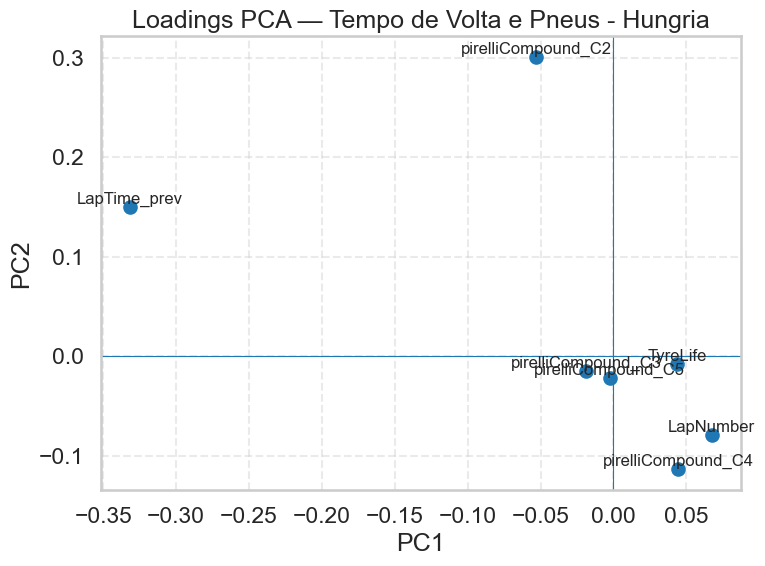

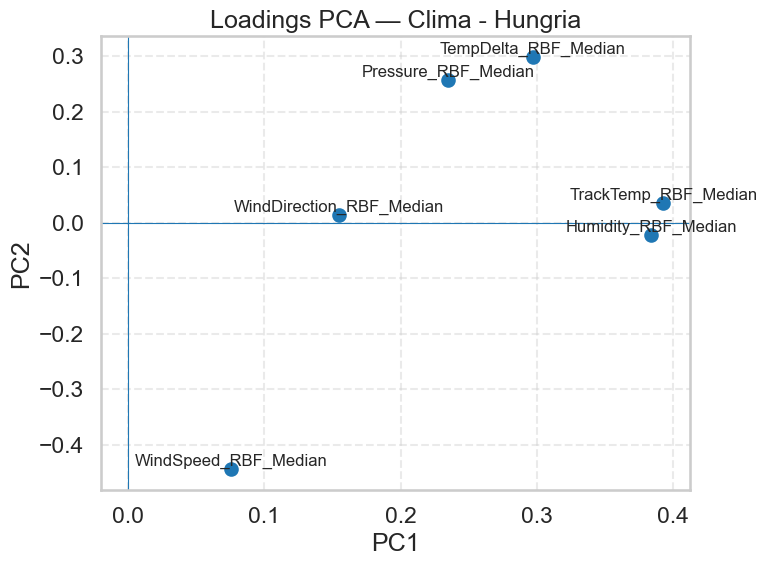

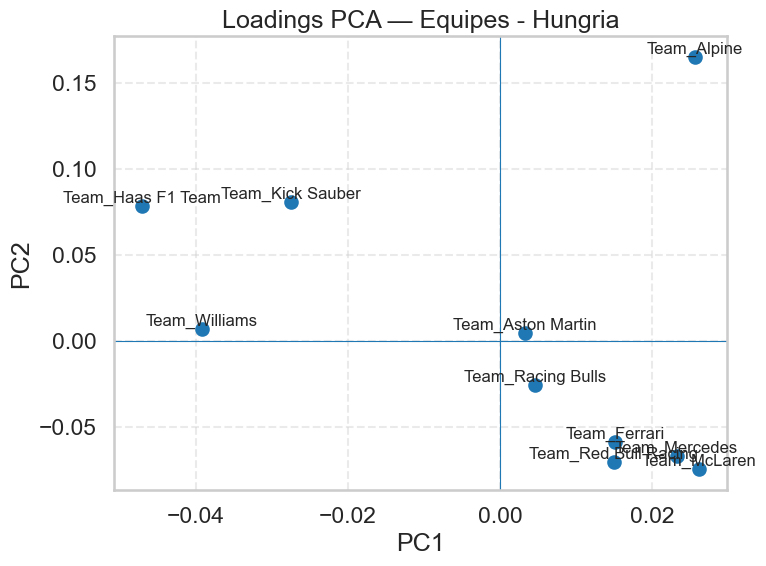

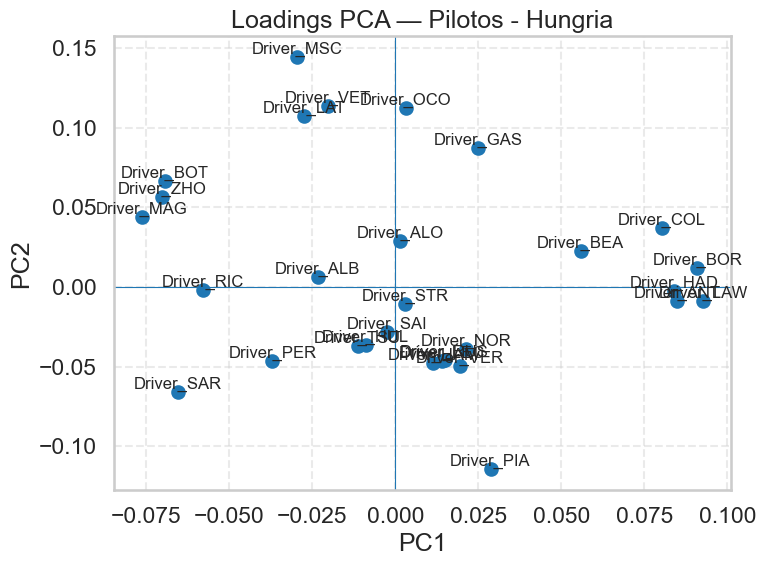

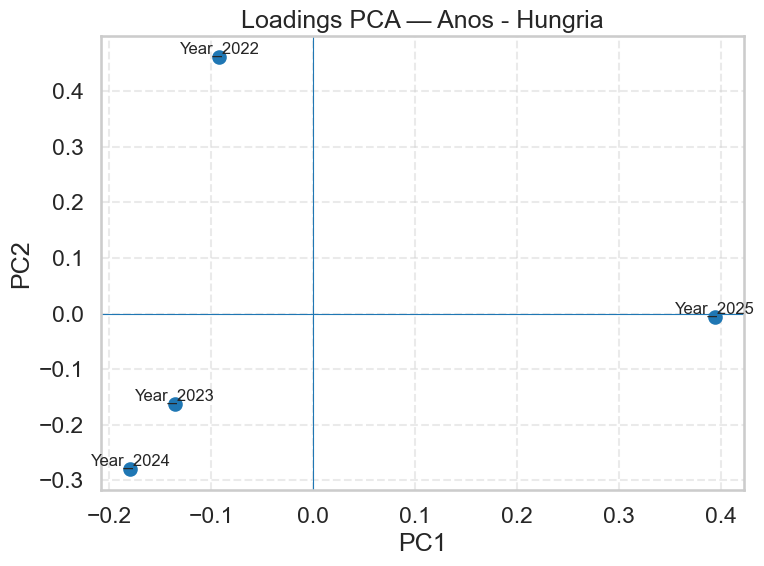

In [23]:
def plot_pca_loadings_subset_2d_static(pca, subset_features, full_feature_names, title):
    loadings = pca.components_.T
    pc1 = loadings[:, 0]
    pc2 = loadings[:, 1]

    if not isinstance(full_feature_names, pd.Index):
        full_feature_names = pd.Index(full_feature_names)

    subset_features = [f for f in subset_features if f in full_feature_names]
    if len(subset_features) == 0:
        print(f"[AVISO] Nenhuma feature encontrada: {title}")
        return

    idx = [full_feature_names.get_loc(f) for f in subset_features]

    plt.figure(figsize=(8, 6))
    plt.scatter(pc1[idx], pc2[idx])

    for i, feat in zip(idx, subset_features):
        plt.text(pc1[i], pc2[i], feat, fontsize=12, ha='center', va='bottom')

    plt.axhline(0, linewidth=0.8)
    plt.axvline(0, linewidth=0.8)

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(title)
    plt.grid(True, linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()

feature_names = ml_df_imputed_analysis.columns
plot_pca_loadings_subset_2d_static(
    pca,
    [
        'LapTime_prev', 'TyreLife', 'LapNumber',
        'pirelliCompound_C5', 'pirelliCompound_C4', 'pirelliCompound_C3', 'pirelliCompound_C2'
    ],
    feature_names,
    "Loadings PCA — Tempo de Volta e Pneus - Hungria"
)

plot_pca_loadings_subset_2d_static(
    pca,
    [
        'Humidity_RBF_Median', 'Pressure_RBF_Median', 'WindSpeed_RBF_Median',
        'TrackTemp_RBF_Median', 'TempDelta_RBF_Median', 'WindDirection_RBF_Median'
    ],
    feature_names,
    "Loadings PCA — Clima - Hungria"
)

plot_pca_loadings_subset_2d_static(
    pca,
    [c for c in feature_names if c.startswith("Team_")],
    feature_names,
    "Loadings PCA — Equipes - Hungria"
)

plot_pca_loadings_subset_2d_static(
    pca,
    [c for c in feature_names if c.startswith("Driver_")],
    feature_names,
    "Loadings PCA — Pilotos - Hungria"
)

# Anos
plot_pca_loadings_subset_2d_static(
    pca,
    [c for c in feature_names if c.startswith("Year_")],
    feature_names,
    "Loadings PCA — Anos - Hungria"
)


## 16. Modelagem Preditiva: Estabelecimento do Baseline (Regressão Linear)

Antes de aplicar algoritmos complexos de "caixa preta" (como Gradient Boosting), é boa prática científica estabelecer um **Baseline** utilizando um modelo linear simples e interpretável.

O objetivo da **Regressão Linear Múltipla** aqui é duplo:
1.  **Definir um Benchmark:** Estabelecer o erro mínimo aceitável (RMSE) e a explicação de variância ($R^2$) que qualquer modelo avançado deve superar.
2.  **Validar Relações Físicas:** Analisar os coeficientes ($\beta$) para confirmar se as variáveis se comportam conforme a física (ex: `TyreLife` deve ter coeficiente positivo, aumentando o tempo).

### Pré-processamento Rigoroso para Modelos Lineares:
Diferente de árvores de decisão, a regressão linear é sensível à escala e multicolineariedade. Por isso, aplicamos:

* **Prevenção da Armadilha das Variáveis Dummy:** Ao usar *One-Hot Encoding* em variáveis categóricas (Equipes, Pilotos), utilizamos `drop_first=True`. Isso remove uma coluna de cada categoria (ex: remove a equipe 'Ferrari' e a usa como referência), evitando a **Multicolineariedade Perfeita** (onde uma variável pode ser prevista perfeitamente pelas outras), que quebraria a inversão da matriz algébrica.
* **Padronização (`StandardScaler`):** Transformamos todas as variáveis numéricas para a mesma escala (Média=0, Desvio Padrão=1). Sem isso, o coeficiente de `Pressure` (~1000 hPa) seria artificialmente minúsculo comparado ao de `TyreLife` (~10 voltas), tornando a interpretação dos pesos impossível.

In [24]:
target_col = 'LapTime_seconds'
num_cols = [
    'TyreLife', 'LapNumber',
    'Humidity_RBF_Median','Pressure_RBF_Median', 'TrackTemp_RBF_Median', 
    'WindSpeed_RBF_Median', 'TempDelta_RBF_Median', 'WindDirection_RBF_Median', 'LapTime_prev'
]
cat_cols = ['Driver', 'Team', 'pirelliCompound', 'Year']

print("Preparando dados para Regressão Linear (Baseline)...")

num_cols = [c for c in num_cols if c in laps_cleaned.columns]
cat_cols = [c for c in cat_cols if c in laps_cleaned.columns]

X_base = laps_cleaned[num_cols + cat_cols].copy()
y = laps_cleaned[target_col].copy()

valid_indices = y.dropna().index
X_base = X_base.loc[valid_indices]
y = y.loc[valid_indices]

X_encoded = pd.get_dummies(X_base, columns=cat_cols, drop_first=True)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

imputer = SimpleImputer(strategy='mean')
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train_raw), columns=X_train_raw.columns)
X_test_imputed = pd.DataFrame(imputer.transform(X_test_raw), columns=X_test_raw.columns)

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train_imputed), columns=X_train_imputed.columns)
X_test = pd.DataFrame(scaler.transform(X_test_imputed), columns=X_test_imputed.columns)

print(f"Shape final de X_train: {X_train.shape}")
print(f"Shape final de X_test: {X_test.shape}")

print("Treinando Regressão Linear...")
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred_train = model_lr.predict(X_train)
y_pred_test = model_lr.predict(X_test)

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print("\n--- RESULTADOS DO BASELINE (Regressão Linear) ---")
print(f"RMSE (Erro Médio Quadrático): {rmse_test:.4f} segundos")
print(f"MAE (Erro Médio Absoluto):    {mae_test:.4f} segundos")
print(f"R² (Coef. de Determinação):   {r2_test:.4f}")

coefs = pd.DataFrame({'Feature': X_train.columns, 'Coef': model_lr.coef_})
coefs['Abs_Coef'] = coefs['Coef'].abs()
print("\nVariáveis Mais Impactantes:")
display(coefs.sort_values(by='Abs_Coef', ascending=False))

Preparando dados para Regressão Linear (Baseline)...
Shape final de X_train: (3370, 52)
Shape final de X_test: (843, 52)
Treinando Regressão Linear...

--- RESULTADOS DO BASELINE (Regressão Linear) ---
RMSE (Erro Médio Quadrático): 0.3305 segundos
MAE (Erro Médio Absoluto):    0.2570 segundos
R² (Coef. de Determinação):   0.9530

Variáveis Mais Impactantes:


,Feature,Coef,Abs_Coef
8,LapTime_prev,1.238229,1.238229
51,Year_2025,-0.306626,0.306626
1,LapNumber,-0.150593,0.150593
4,TrackTemp_RBF_Median,0.137764,0.137764
0,TyreLife,0.095917,0.095917
3,Pressure_RBF_Median,0.060913,0.060913
2,Humidity_RBF_Median,-0.055092,0.055092
27,Driver_PIA,-0.048079,0.048079
24,Driver_NOR,-0.046593,0.046593
50,Year_2024,0.040934,0.040934


---

## 17. Validação do Baseline - Diagnóstico de Resíduos

### Por Quê Analisar Resíduos?
Erro médio (RMSE, R²) mascara problemas estruturais. Resíduos revelam:
- Se o modelo é enviesado (estimativa sistemática alta/baixa)
- Se as premissas do OLS são violadas
- Onde o modelo falha


### Os 4 Gráficos Diagnósticos- **Alerta:** Nuvem dispersa → R² baixo

- **Ideal:** Pontos próximos à reta y=x (ρ ≈ 1)

#### 1. **Resíduos vs Valores Preditos**- **Propósito:** Acurácia visual do ajuste

- **Propo:** Homoscedasticidade (variância constante dos erros)#### 4. **Real vs Predito**

- **Ideal:** Nuvem aleatória sem padrão

- **Alerta:** Forma de funil → erros maiores em predições mais altas (heteroscedasticidade)- **Alerta:** Padrão de onda → dependência temporal não capturada (falta feature temporal)

- **Ideal:** Aleatoriedade, sem padrão temporal

#### 2. **QQ-Plot (Normal Probability Plot)**- **Propósito:** Independência (sem autocorrelação)

- **Propósito:** Normalidade dos resíduos#### 3. **Resíduos vs Ordem (Índice)**

- **Ideal:** Pontos seguem linha diagonal vermelha
- **Alerta:** Desvios nas caudas → distribuição com caudas pesadas (outliers frequentes)

Gerando diagnósticos para Regressão Linear...


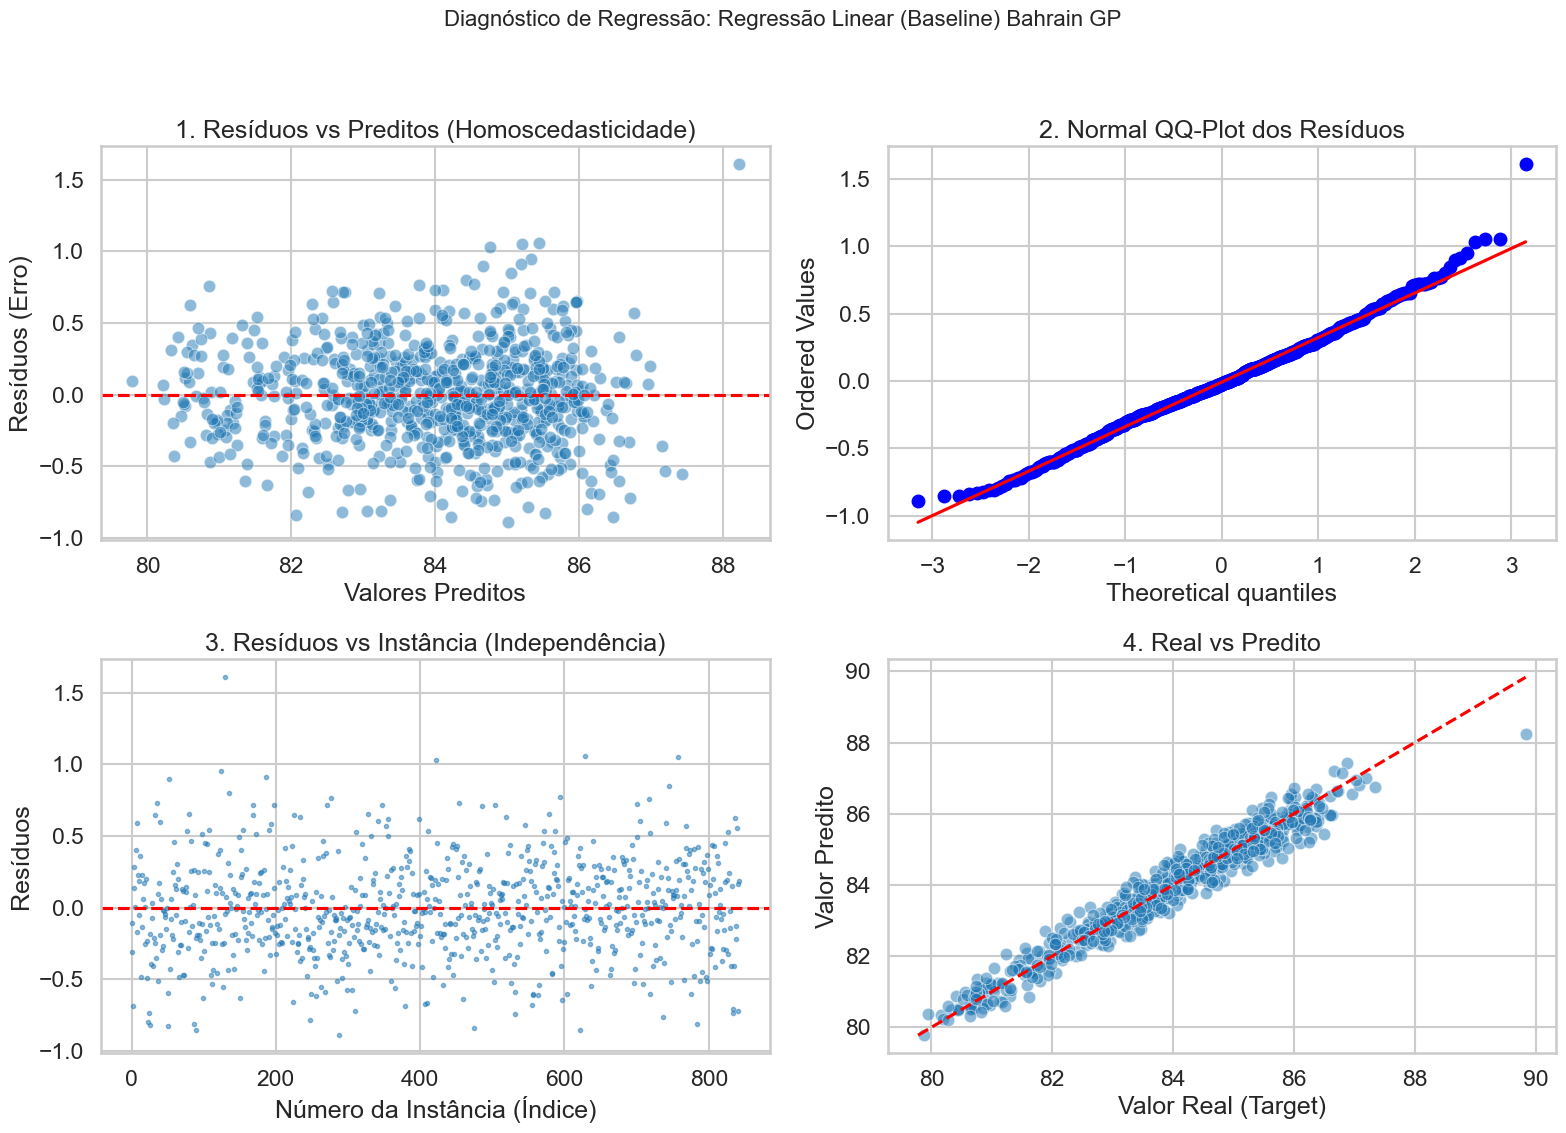

In [25]:
def plot_regression_diagnostics(y_true, y_pred, model_name):
    residuals = y_true - y_pred
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'Diagnóstico de Regressão: {model_name}', fontsize=16)
    
    sns.scatterplot(x=y_pred, y=residuals, ax=axes[0, 0], alpha=0.5)
    axes[0, 0].axhline(0, color='red', linestyle='--')
    axes[0, 0].set_xlabel('Valores Preditos')
    axes[0, 0].set_ylabel('Resíduos (Erro)')
    axes[0, 0].set_title('1. Resíduos vs Preditos (Homoscedasticidade)')
    
    stats.probplot(residuals, dist="norm", plot=axes[0, 1])
    axes[0, 1].set_title('2. Normal QQ-Plot dos Resíduos')
    
    axes[1, 0].plot(residuals.values, marker='o', linestyle='none', alpha=0.5, markersize=3)
    axes[1, 0].axhline(0, color='red', linestyle='--')
    axes[1, 0].set_xlabel('Número da Instância (Índice)')
    axes[1, 0].set_ylabel('Resíduos')
    axes[1, 0].set_title('3. Resíduos vs Instância (Independência)')
    
    sns.scatterplot(x=y_true, y=y_pred, ax=axes[1, 1], alpha=0.5)
    
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    axes[1, 1].plot([min_val, max_val], [min_val, max_val], 'r--')
    
    axes[1, 1].set_xlabel('Valor Real (Target)')
    axes[1, 1].set_ylabel('Valor Predito')
    axes[1, 1].set_title('4. Real vs Predito')
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

def calculate_confidence_intervals(y_true, y_pred, metric_func, metric_name, n_bootstraps=1000):
    bootstrapped_scores = []
    rng = np.random.RandomState(42)
    
    y_true = y_true.reset_index(drop=True)
    y_pred = pd.Series(y_pred)
    
    for i in range(n_bootstraps):
        indices = rng.randint(0, len(y_pred), len(y_pred))
        if len(np.unique(y_true[indices])) < 2:
            continue
            
        score = metric_func(y_true[indices], y_pred[indices])
        if metric_name == 'RMSE':
             score = np.sqrt(score)
             
        bootstrapped_scores.append(score)
        
    sorted_scores = np.array(bootstrapped_scores)
    sorted_scores.sort()
    
    confidence_lower = sorted_scores[int(0.025 * len(sorted_scores))]
    confidence_upper = sorted_scores[int(0.975 * len(sorted_scores))]
    mean_score = np.mean(sorted_scores)
    
    return mean_score, confidence_lower, confidence_upper
print("Gerando diagnósticos para Regressão Linear...")
plot_regression_diagnostics(y_test, y_pred_test, "Regressão Linear (Baseline) Bahrain GP")

In [26]:
print("Ajustando índices para o Statsmodels...")

X_train_reset = X_train.reset_index(drop=True)
y_train_reset = y_train.reset_index(drop=True)

X_train_sm = sm.add_constant(X_train_reset)

print("Treinando modelo OLS...")
model_sm = sm.OLS(y_train_reset, X_train_sm).fit()

print(model_sm.summary())

r2_test_sm = r2_score(y_test, y_pred_test)
rmse_test_sm = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test_sm = mean_absolute_error(y_test, y_pred_test)
print("\n--- RESULTADOS DO BASELINE no Conjunto de teste (Statsmodels OLS) ---")
print(f"RMSE (Erro Médio Quadrático): {rmse_test_sm:.4f} segundos")
print(f"MAE (Erro Médio Absoluto):    {mae_test_sm:.4f} segundos")
print(f"R² (Coef. de Determinação):   {r2_test_sm:.4f}")


Ajustando índices para o Statsmodels...
Treinando modelo OLS...
                            OLS Regression Results                            
Dep. Variable:        LapTime_seconds   R-squared:                       0.953
Model:                            OLS   Adj. R-squared:                  0.952
Method:                 Least Squares   F-statistic:                     1325.
Date:                Thu, 02 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:49:22   Log-Likelihood:                -1043.3
No. Observations:                3370   AIC:                             2191.
Df Residuals:                    3318   BIC:                             2509.
Df Model:                          51                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------

---

## 18. Seleção de Variáveis - Backward Elimination com IC's

### Problema: Overfitting
46 features → modelo treina em ruído, generaliza mal

### Solução: Seleção Automática
**Backward Elimination** com teste estatístico rigoroso:

#### Algoritmo
1. **Início:** Treina com TODAS as features
2. **Iteração k:**
   - Calcula p-valor para cada variável

   - Remove a com maior p-valor (menos significativa)**Resultado esperado:** 46 features → ~15 features relevantes (redução 67%) com mesmo desempenho

3. **Parada:** Quando todos p-valores < 0.05

- **Conclusão:** Remover a variável não prejudica performance (estatisticamente)

#### Inovação Deste TCC: Intervalos de Confiança (IC)- Se $\text{IC}_{k} \cap \text{IC}_{k-1} \neq \emptyset$ → Sobreposição → Sem perda significativa

A cada eliminação, calcula **IC 95% do RMSE** via Bootstrap:**Critério de Segurança:**


$$\text{IC}_{95\%} = \left[\text{RMSE} - 1.96 \times \text{SE}, \text{RMSE} + 1.96 \times \text{SE}\right]$$

### Execução: Testagem Iterativa
Implementamos múltiplas estratégias:
- Remover categorias inteiras (ex: todos os dummies de Driver)

- Remover features colineares (r > 0.95)- Validar cruzado em cada passo
- Remover non-significant (p > 0.10)

In [27]:
def calculate_metrics_and_ci(residuals, confidence=0.95):
    squared_errors = residuals ** 2
    mse = squared_errors.mean()
    rmse_val = np.sqrt(mse)
    
    mse_ci = stats.t.interval(confidence, len(squared_errors)-1, 
                              loc=mse, scale=stats.sem(squared_errors))
    rmse_ci = (np.sqrt(max(0, mse_ci[0])), np.sqrt(mse_ci[1]))
    
    abs_errors = np.abs(residuals)
    mae_val = abs_errors.mean()
    mae_ci = stats.t.interval(confidence, len(abs_errors)-1, 
                              loc=mae_val, scale=stats.sem(abs_errors))
    
    return rmse_val, rmse_ci, mae_val, mae_ci

print("Calculando Baseline (Modelo Completo)...")
n_obs = len(y_train)

full_model = sm.OLS(y_train.values, X_train_sm).fit()

rmse_full, ci_rmse_full, mae_full, ci_mae_full = calculate_metrics_and_ci(full_model.resid)

print(f"BASELINE (Full):")
print(f"  RMSE: {rmse_full:.4f} | IC 95%: [{ci_rmse_full[0]:.4f}, {ci_rmse_full[1]:.4f}]")
print(f"  MAE:  {mae_full:.4f} | IC 95%: [{ci_mae_full[0]:.4f}, {ci_mae_full[1]:.4f}]")

features = list(X_train_sm.columns)
history = []

print("\nIniciando Backward Elimination...")
header = f"{'Passo':<5} | {'Var. Removida':<26} | {'P-val':<8} | {'RMSE (IC 95%)':<28} | {'MAE (IC 95%)':<28} | {'Sig?':<5}"
print("-" * len(header))
print(header)
print("-" * len(header))

step = 0
while len(features) > 0:
    X_curr = X_train_sm[features]
    model = sm.OLS(y_train.values, X_curr).fit()
    
    rmse_curr, ci_rmse_curr, mae_curr, ci_mae_curr = calculate_metrics_and_ci(model.resid)
    
    rss = model.ssr 
    p = len(features)
    rmse_overlap = not (ci_rmse_curr[0] > ci_rmse_full[1])
    significativo = "NAO" if rmse_overlap else "SIM!"

    p_values = model.pvalues
    max_p_value = p_values.max()
    worst_feature = p_values.idxmax()
    
    if max_p_value > 0.05:
        features.remove(worst_feature)
        
        rmse_str = f"{rmse_curr:.3f} [{ci_rmse_curr[0]:.3f}, {ci_rmse_curr[1]:.3f}]"
        mae_str = f"{mae_curr:.3f} [{ci_mae_curr[0]:.3f}, {ci_mae_curr[1]:.3f}]"
        
        history.append({
            'Step': step,
            'Removed': worst_feature,
            'RMSE': rmse_curr,
            'RMSE_Lower': ci_rmse_curr[0],
            'RMSE_Upper': ci_rmse_curr[1],
            'Significant_Change': significativo
        })
        
        print(f"{step:<5} | {worst_feature:<26} | {max_p_value:.4f}   | {rmse_str:<28} | {mae_str:<28} | {significativo:<5}")
        step += 1
    else:
        print("-" * len(header))
        print(f"Parada! P-values < 0.05.")
        print(f"Modelo Final: {len(features)} variáveis.")
        print(f"RMSE Final: {rmse_curr:.4f} [{ci_rmse_curr[0]:.4f}, {ci_rmse_curr[1]:.4f}]")
        break


print("\nVariáveis Finais:")
print(features)
final_model = sm.OLS(y_train.values, X_train_sm[features]).fit()
print(final_model.summary())

Calculando Baseline (Modelo Completo)...
BASELINE (Full):
  RMSE: 0.3298 | IC 95%: [0.3202, 0.3390]
  MAE:  0.2505 | IC 95%: [0.2433, 0.2578]

Iniciando Backward Elimination...
-------------------------------------------------------------------------------------------------------------------
Passo | Var. Removida              | P-val    | RMSE (IC 95%)                | MAE (IC 95%)                 | Sig? 
-------------------------------------------------------------------------------------------------------------------
0     | Driver_SAI                 | 0.9550   | 0.330 [0.320, 0.339]         | 0.251 [0.243, 0.258]         | NAO  
1     | Team_Haas F1 Team          | 0.8213   | 0.330 [0.320, 0.339]         | 0.251 [0.243, 0.258]         | NAO  
2     | Driver_HAM                 | 0.8056   | 0.330 [0.320, 0.339]         | 0.251 [0.243, 0.258]         | NAO  
3     | Team_Racing Bulls          | 0.7267   | 0.330 [0.320, 0.339]         | 0.251 [0.243, 0.258]         | NAO  
4     | Dri

In [28]:
def calc_stats(values):
    mean_v = np.mean(values)
    ci = stats.t.interval(
        0.95,
        len(values) - 1,
        loc=mean_v,
        scale=stats.sem(values)
    )
    return mean_v, ci[0], ci[1]


## 19. Refinamento do Baseline (5 Splits)

Para garantir uma comparação estatisticamente justa com o modelo avançado (XGBoost), submetemos o **Baseline Linear** ao mesmo protocolo de validação rigorosa.

Em vez de confiar em uma única divisão de Treino/Teste (que pode ser "sortuda" ou "azarada"), realizamos:
1.  **5 Divisões Aleatórias (Splits):** Separamos os dados em 80/20 cinco vezes, mudando a semente aleatória (`random_state`) em cada iteração.
2.  **Cálculo de ICs:** Geramos a média e o Intervalo de Confiança (95%) para RMSE, MAE e $R^2$.

**Objetivo:** Se o limite inferior do intervalo de confiança do XGBoost for maior que o limite superior deste Baseline, teremos a prova definitiva e irrefutável de que a não-linearidade é necessária para modelar este problema.

In [29]:
print("--- PREPARAÇÃO E VALIDAÇÃO ROBUSTA DO BASELINE ---")

target_col = 'LapTime_seconds'
df_base = laps_cleaned.copy() 

num_cols_base = [
    'TyreLife', 'LapNumber',
    'Humidity_RBF_Median','Pressure_RBF_Median', 'TrackTemp_RBF_Median', 
    'WindSpeed_RBF_Median',
    'TempDelta_RBF_Median', 'LapTime_prev'
]

cat_cols_base = ['Driver', 'Team', 'pirelliCompound', 'Year']

num_cols_base = [c for c in num_cols_base if c in df_base.columns]
cat_cols_base = [c for c in cat_cols_base if c in df_base.columns]

X_raw = df_base[num_cols_base + cat_cols_base].copy()
y_raw = df_base[target_col].copy()

valid_indices = y_raw.dropna().index
X_raw = X_raw.loc[valid_indices]
y_raw = y_raw.loc[valid_indices]

X_encoded = pd.get_dummies(X_raw, columns=cat_cols_base, drop_first=True)
y_final = y_raw

print(f"Dados codificados. Shape X: {X_encoded.shape}, Shape y: {y_final.shape}")

np.random.seed(42)

results_baseline = {
    'seed_usada': [], 
    'rmse': [],
    'mae': [],
    'r2': []
}

N_SPLITS = 5

for i in range(N_SPLITS):
    seed_da_rodada = np.random.randint(0, 100000)
    
    print(f"\nSplit {i+1}/{N_SPLITS} | Seed Sorteada: {seed_da_rodada}")
    X_tr_raw, X_te_raw, y_tr, y_te = train_test_split(
        X_encoded, y_final, 
        test_size=0.20, 
        random_state=seed_da_rodada, 
        shuffle=True
    )
    
    imputer = SimpleImputer(strategy='mean')
    X_tr_imp = pd.DataFrame(imputer.fit_transform(X_tr_raw), columns=X_tr_raw.columns)
    X_te_imp = pd.DataFrame(imputer.transform(X_te_raw), columns=X_te_raw.columns)

    scaler = StandardScaler()
    X_tr_scaled = pd.DataFrame(scaler.fit_transform(X_tr_imp), columns=X_tr_imp.columns)
    X_te_scaled = pd.DataFrame(scaler.transform(X_te_imp), columns=X_te_imp.columns)
    
    model = LinearRegression()
    model.fit(X_tr_scaled, y_tr)
    
    preds = model.predict(X_te_scaled)
    
    rmse_val = np.sqrt(mean_squared_error(y_te, preds))
    mae_val = mean_absolute_error(y_te, preds)
    r2_val = r2_score(y_te, preds)
    
    results_baseline['seed_usada'].append(seed_da_rodada)
    results_baseline['rmse'].append(rmse_val)
    results_baseline['mae'].append(mae_val)
    results_baseline['r2'].append(r2_val)
    
    print(f"   Resultado: RMSE={rmse_val:.4f} | MAE={mae_val:.4f} | R2={r2_val:.4f}")

def calc_stats(values):
    mean_v = np.mean(values)
    ci = stats.t.interval(0.95, len(values)-1, loc=mean_v, scale=stats.sem(values))
    return mean_v, ci[0], ci[1]

rmse_m, rmse_l, rmse_u = calc_stats(results_baseline['rmse'])
mae_m, mae_l, mae_u = calc_stats(results_baseline['mae'])
r2_m, r2_l, r2_u = calc_stats(results_baseline['r2'])

mean_rmse_lr, lower_rmse_lr, upper_rmse_lr = rmse_m, rmse_l, rmse_u
mean_mae_lr, lower_mae_lr, upper_mae_lr = mae_m, mae_l, mae_u
mean_r2_lr, lower_r2_lr, upper_r2_lr = r2_m, r2_l, r2_u

print("\n--- RESULTADOS FINAIS DO BASELINE ROBUSTO ---")
print(f"RMSE: {rmse_m:.4f}  IC95%: [{rmse_l:.4f}, {rmse_u:.4f}]")
print(f"MAE:  {mae_m:.4f}  IC95%: [{mae_l:.4f}, {mae_u:.4f}]")
print(f"R²:   {r2_m:.4f}  IC95%: [{r2_l:.4f}, {r2_u:.4f}]")

df_res_base = pd.DataFrame(results_baseline)

--- PREPARAÇÃO E VALIDAÇÃO ROBUSTA DO BASELINE ---
Dados codificados. Shape X: (4213, 51), Shape y: (4213,)

Split 1/5 | Seed Sorteada: 15795
   Resultado: RMSE=0.3348 | MAE=0.2559 | R2=0.9543

Split 2/5 | Seed Sorteada: 860
   Resultado: RMSE=0.3302 | MAE=0.2523 | R2=0.9548

Split 3/5 | Seed Sorteada: 76820
   Resultado: RMSE=0.3260 | MAE=0.2517 | R2=0.9566

Split 4/5 | Seed Sorteada: 54886
   Resultado: RMSE=0.3348 | MAE=0.2595 | R2=0.9512

Split 5/5 | Seed Sorteada: 6265
   Resultado: RMSE=0.3397 | MAE=0.2575 | R2=0.9480

--- RESULTADOS FINAIS DO BASELINE ROBUSTO ---
RMSE: 0.3331  IC95%: [0.3267, 0.3396]
MAE:  0.2554  IC95%: [0.2512, 0.2595]
R²:   0.9530  IC95%: [0.9488, 0.9572]


## 19. Machine Learning II: Modelo Avançado (XGBoost + Otimização)

### Por Quê Ir Além do Linear?
**Limitações da Regressão Linear (OLS):**
* Assume relação estritamente linear: $\mathbb{E}[Y|X] = \beta_0 + \sum \beta_i X_i$
* Falha em capturar interações complexas (ex: "A performance cai drasticamente se o `TyreLife` for alto **E** a `TrackTemp` for muito quente").
* Relações severamente não-lineares causam *underfitting*.

### A Solução: XGBoost (eXtreme Gradient Boosting)
* **Ensemble de Árvores de Decisão:** Combina múltiplos preditores fracos.
* **Aprendizado Iterativo (Boosting):** Cada nova árvore tenta corrigir os erros da árvore anterior.
* **Interações Automáticas:** Captura relações não-lineares sem a necessidade de criar termos de interação manualmente.
* **Regularização Integrada:** Possui mecanismos *built-in* para penalizar a complexidade e evitar *overfitting*.

---

### Pipeline de Validação Robusta (3 Camadas)

#### 1️⃣ Tunagem de Hiperparâmetros
Busca no espaço combinatório para encontrar a melhor configuração. **Validação Interna:** Um 5-Fold CV é aplicado em cada combinação para definir o melhor hiperparâmetro global.
* `max_depth`: [3, 5, 7] *(profundidade máxima da árvore)*
* `learning_rate`: [0.01, 0.05, 0.1] *(tamanho do passo a cada iteração)*
* `n_estimators`: [100, 300, 500] *(número total de árvores)*
* `subsample`: [0.7, 0.8] *(fração de dados usada por árvore)*
* `colsample_bytree`: [0.7, 0.8] *(fração de features usada por árvore)*

#### 2️⃣ Monte Carlo Cross-Validation (5 Split Runs)
Comprova que o modelo não "teve sorte" em uma única divisão de treino/teste (*data split bias*).
* **Split 1:** Random seed 42 → Treina XGBoost → Calcula $\text{RMSE}_1$
* **Split 2:** Random seed 123 → Treina XGBoost → Calcula $\text{RMSE}_2$
* **...**
* **Split 5:** Random seed 999 → Treina XGBoost → Calcula $\text{RMSE}_5$
* **Resultado:** Um conjunto de métricas $\{ \text{RMSE}_1, \text{RMSE}_2, \dots, \text{RMSE}_5 \}$

#### 3️⃣ Estimativa de Intervalo de Confiança (IC 95%)
A partir das métricas dos 5 splits, calcula-se o **IC 95%** utilizando a estatística t-Student:
$$\text{IC}_{95\%} = \left[ \bar{\text{RMSE}} \pm t_{critical} \times \text{SE} \right]$$

**Resultado Final (Exemplo):**
$$\text{R}^2 = 0.92 \pm 0.03 \text{ (IC 95\%)}$$

---

### Benefícios da Abordagem

* 🔬 **Ciência:** Estabelece um padrão de excelência metodológica em *Machine Learning*.
* ⚖️ **Honestidade:** Quantifica a incerteza estatística ($\pm$ IC), fugindo da ilusão de uma métrica pontual perfeita.
* 🔄 **Reprodutibilidade:** Garante que o desempenho não dependa de um corte sortudo (*lucky split*) dos dados.

> **Interpretação:** Com 95% de confiança, o $R^2$ do modelo está contido no intervalo estimado, **independentemente de como os dados são divididos**. Resultado robusto e validado! ✅

In [30]:
print("--- PREPARAÇÃO PARA XGBOOST (SEM ONE_HOT_THRESH, DRIVER ONE-HOT) ---")

X_proc = X_raw.copy()

X_proc[cat_cols] = X_proc[cat_cols].fillna("Missing")

X_proc = pd.get_dummies(X_proc, columns=cat_cols, drop_first=True)

X_proc[num_cols_base] = X_proc[num_cols_base].fillna(X_proc[num_cols_base].median())

X = X_proc
y = y_raw.copy()

X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y, test_size=0.20, random_state=42
)


rf = RandomForestRegressor(random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_holdout)
rf_rmse = np.sqrt(mean_squared_error(y_holdout, rf_preds))
rf_r2 = r2_score(y_holdout, rf_preds)
rf_mae = mean_absolute_error(y_holdout, rf_preds)

print("Random Forest RMSE:", rf_rmse)
print("Random Forest R2:", rf_r2)
print("Random Forest MAE:", rf_mae)


dtrain = xgb.DMatrix(X_train, label=y_train)
dvalid = xgb.DMatrix(X_holdout, label=y_holdout)

base_params = {
    "objective": "reg:squarederror",
    "tree_method": "hist",
    "eval_metric": "rmse",
    "seed": 42,
}

baseline = xgb.train(
    params=base_params,
    dtrain=dtrain,
    num_boost_round=200,
    evals=[(dvalid, "validation")],
    early_stopping_rounds=20,
    verbose_eval=False
)

preds = baseline.predict(dvalid, iteration_range=(0, baseline.best_iteration + 1))
baseline_rmse_xgb = np.sqrt(mean_squared_error(y_holdout, preds))
baseline_mae_xgb = mean_absolute_error(y_holdout, preds)
baseline_r2_xgb = r2_score(y_holdout, preds)

print("Baseline XGB RMSE:", baseline_rmse_xgb)
print("Baseline XGB MAE:", baseline_mae_xgb)
print("Baseline XGB R2:", baseline_r2_xgb)

params = {
    "objective": "reg:squarederror",
    "tree_method": "hist",
    "eval_metric": "rmse",
    "learning_rate": 0.05,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "seed": 42,
}

simple = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=2000,
    evals=[(dvalid, "validation")],
    early_stopping_rounds=50,
    verbose_eval=False
)

preds = simple.predict(dvalid, iteration_range=(0, simple.best_iteration + 1))
simple_rmse = np.sqrt(mean_squared_error(y_holdout, preds))
simple_mae = mean_absolute_error(y_holdout, preds)
simple_r2 = r2_score(y_holdout, preds)

print("Simple Model RMSE:", simple_rmse)
print("Simple Model MAE:", simple_mae)
print("Simple Model R2:", simple_r2)

print("\n--- TUNAGEM OPTUNA ---")

def objective(trial):
    param = {
        "objective": "reg:squarederror",
        "tree_method": "hist",
        "eval_metric": "rmse",
        "seed": 42,

        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }

    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    rmse_scores = []

    for train_idx, val_idx in kf.split(X_train):
        dtr = xgb.DMatrix(X_train.iloc[train_idx], label=y_train.iloc[train_idx])
        dva = xgb.DMatrix(X_train.iloc[val_idx], label=y_train.iloc[val_idx])

        bst = xgb.train(
            params=param,
            dtrain=dtr,
            num_boost_round=2000,
            evals=[(dva, "validation")],
            early_stopping_rounds=50,
            verbose_eval=False
        )

        preds = bst.predict(dva, iteration_range=(0, bst.best_iteration + 1))
        rmse_scores.append(np.sqrt(mean_squared_error(y_train.iloc[val_idx], preds)))

    return float(np.mean(rmse_scores))

study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42)
)

study.optimize(objective, n_trials=40, show_progress_bar=False)

best_params = study.best_params
print("\nBest params (Optuna):")
print(best_params)
print("Best CV RMSE:", study.best_value)

best_params_train = {
    "objective": "reg:squarederror",
    "tree_method": "hist",
    "eval_metric": "rmse",
    "seed": 42,
    **best_params
}

dtrain_full = xgb.DMatrix(X_train, label=y_train)
dhold = xgb.DMatrix(X_holdout, label=y_holdout)

final = xgb.train(
    params=best_params_train,
    dtrain=dtrain_full,
    num_boost_round=5000,
    evals=[(dhold, "validation")],
    early_stopping_rounds=100,
    verbose_eval=50
)

final_preds = final.predict(dhold, iteration_range=(0, final.best_iteration + 1))
final_rmse = np.sqrt(mean_squared_error(y_holdout, final_preds))
final_mae = mean_absolute_error(y_holdout, final_preds)
final_r2 = r2_score(y_holdout, final_preds)
print("Final RMSE:", final_rmse)
print("Final MAE:", final_mae)
print("Final R2:", final_r2)


print("\n--- CALIBRANDO N_ESTIMATORS (xgb.cv) COM BEST PARAMS ---")

cv_results = xgb.cv(
    params=best_params_train,
    dtrain=dtrain_full,
    num_boost_round=5000,
    nfold=3,
    metrics="rmse",
    early_stopping_rounds=100,
    seed=42,
    verbose_eval=False
)

best_n = cv_results.shape[0]
print("Melhor n_estimators (cv):", best_n)

final_params = {
    **best_params,
    "objective": "reg:squarederror",
    "tree_method": "hist",
    "n_estimators": best_n
}

print("\nParâmetros Finais Otimizados (para Monte Carlo):")
print(final_params)

print("\n--- INICIANDO COMPARAÇÃO PAREADA (XGBOOST OPTUNA + EARLY STOPPING POR SPLIT) ---")

results_xgb = {"seed_usada": [], "rmse": [], "mae": [], "r2": []}
seeds_do_baseline = results_baseline["seed_usada"]

optuna_params_train = {
    "objective": "reg:squarederror",
    "tree_method": "hist",
    "eval_metric": "rmse",
    "seed": 42,
    **best_params
}

best_r2 = -np.inf
best_rmse = np.inf
best_mae = np.inf

best_model = None
best_seed = None
best_X_tr = None
best_y_te = None
best_dte = None
best_preds = None

for i, seed in enumerate(seeds_do_baseline):

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y,
        test_size=0.20,
        random_state=seed,
        shuffle=True
    )

    feature_names = list(X_tr.columns)

    dtr = xgb.DMatrix(X_tr, label=y_tr, feature_names=feature_names)
    dte = xgb.DMatrix(X_te, label=y_te, feature_names=feature_names)

    bst = xgb.train(
        params=optuna_params_train,
        dtrain=dtr,
        num_boost_round=5000,
        evals=[(dte, "validation")],
        early_stopping_rounds=100,
        verbose_eval=False
    )

    preds = bst.predict(dte, iteration_range=(0, bst.best_iteration + 1))

    rmse_val = np.sqrt(mean_squared_error(y_te, preds))
    mae_val  = mean_absolute_error(y_te, preds)
    r2_val   = r2_score(y_te, preds)

    results_xgb["seed_usada"].append(seed)
    results_xgb["rmse"].append(rmse_val)
    results_xgb["mae"].append(mae_val)
    results_xgb["r2"].append(r2_val)


    is_better = (
        (rmse_val < best_rmse) or
        (np.isclose(rmse_val, best_rmse) and r2_val > best_r2) or
        (np.isclose(rmse_val, best_rmse) and np.isclose(r2_val, best_r2) and mae_val < best_mae)
    )

    if is_better:
        best_r2 = r2_val
        best_rmse = rmse_val
        best_mae = mae_val

        best_model = bst
        best_seed = seed
        best_X_tr = X_tr.copy()
        best_y_te = y_te.copy()
        best_dte = dte
        best_preds = preds

    print(f"Split {i+1} | Seed {seed} | best_iter={bst.best_iteration} | RMSE={rmse_val:.4f} | R2={r2_val:.4f}")

rmse_m_xgb, rmse_l_xgb, rmse_u_xgb = calc_stats(results_xgb["rmse"])
mae_m_xgb, mae_l_xgb, mae_u_xgb = calc_stats(results_xgb["mae"])
r2_m_xgb, r2_l_xgb, r2_u_xgb = calc_stats(results_xgb["r2"])

print("\n--- RESULTADO FINAL XGBOOST (OPTUNA + ES POR SPLIT) ---")
print(f"RMSE Médio: {rmse_m_xgb:.4f} IC95%: [{rmse_l_xgb:.4f}, {rmse_u_xgb:.4f}]")
print(f"MAE  Médio: {mae_m_xgb:.4f} IC95%: [{mae_l_xgb:.4f}, {mae_u_xgb:.4f}]")
print(f"R2   Médio: {r2_m_xgb:.4f} IC95%: [{r2_l_xgb:.4f}, {r2_u_xgb:.4f}]")



--- PREPARAÇÃO PARA XGBOOST (SEM ONE_HOT_THRESH, DRIVER ONE-HOT) ---
Random Forest RMSE: 0.33343834703232544
Random Forest R2: 0.9521831338950687
Random Forest MAE: 0.2535125741399774
Baseline XGB RMSE: 0.3482335422148741
Baseline XGB MAE: 0.2607533816227852
Baseline XGB R2: 0.9478455678115432


[I 2026-04-02 12:49:29,381] A new study created in memory with name: no-name-c8074697-6113-4154-a8aa-4800a227b466


Simple Model RMSE: 0.33789599198913856
Simple Model MAE: 0.2529900436672879
Simple Model R2: 0.950896087040882

--- TUNAGEM OPTUNA ---


[I 2026-04-02 12:49:38,244] Trial 0 finished with value: 0.3358344739134 and parameters: {'learning_rate': 0.030710573677773714, 'max_depth': 10, 'min_child_weight': 8, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'gamma': 0.7799726016810132, 'reg_alpha': 3.3323645788192616e-08, 'reg_lambda': 0.6245760287469893}. Best is trial 0 with value: 0.3358344739134.
[I 2026-04-02 12:49:42,030] Trial 1 finished with value: 0.34833827944179435 and parameters: {'learning_rate': 0.06054365855469246, 'max_depth': 8, 'min_child_weight': 1, 'subsample': 0.9879639408647978, 'colsample_bytree': 0.9329770563201687, 'gamma': 1.0616955533913808, 'reg_alpha': 4.329370014459266e-07, 'reg_lambda': 4.4734294104626844e-07}. Best is trial 0 with value: 0.3358344739134.
[I 2026-04-02 12:49:50,412] Trial 2 finished with value: 0.34061414452953453 and parameters: {'learning_rate': 0.024878734419814436, 'max_depth': 7, 'min_child_weight': 5, 'subsample': 0.7164916560792167, 'colsample_byt


Best params (Optuna):
{'learning_rate': 0.027995972527262394, 'max_depth': 10, 'min_child_weight': 8, 'subsample': 0.8687326690653886, 'colsample_bytree': 0.6533703147413447, 'gamma': 0.4848537215109575, 'reg_alpha': 0.0005405817920566042, 'reg_lambda': 1.111365433801439e-08}
Best CV RMSE: 0.33442895983402154
[0]	validation-rmse:1.48982
[50]	validation-rmse:0.48886
[100]	validation-rmse:0.33910
[150]	validation-rmse:0.32641
[200]	validation-rmse:0.32521
[250]	validation-rmse:0.32481
[300]	validation-rmse:0.32471
[350]	validation-rmse:0.32477
[400]	validation-rmse:0.32475
[424]	validation-rmse:0.32474
Final RMSE: 0.32462346011303916
Final MAE: 0.2442084169580138
Final R2: 0.9546779207766507

--- CALIBRANDO N_ESTIMATORS (xgb.cv) COM BEST PARAMS ---
Melhor n_estimators (cv): 741

Parâmetros Finais Otimizados (para Monte Carlo):
{'learning_rate': 0.027995972527262394, 'max_depth': 10, 'min_child_weight': 8, 'subsample': 0.8687326690653886, 'colsample_bytree': 0.6533703147413447, 'gamma': 


Melhor modelo do XGBoost treinado durante os splits:
Seed: 76820
R2: 0.9579502442881079
RMSE: 0.320764686261973
MAE: 0.2433757409653487


,gain
LapTime_prev,68.671906
Humidity_RBF_Median,30.216066
Pressure_RBF_Median,15.694772
Driver_VER,6.104291
Team_Racing Bulls,5.381549
LapNumber,4.996493
Driver_PER,4.656641
Team_Mercedes,4.457300
Year_2024,4.370435
Driver_LEC,4.158429


C:\Users\mpoli\AppData\Local\Temp\ipykernel_18404\1914103713.py:29: FutureWarning:

The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.



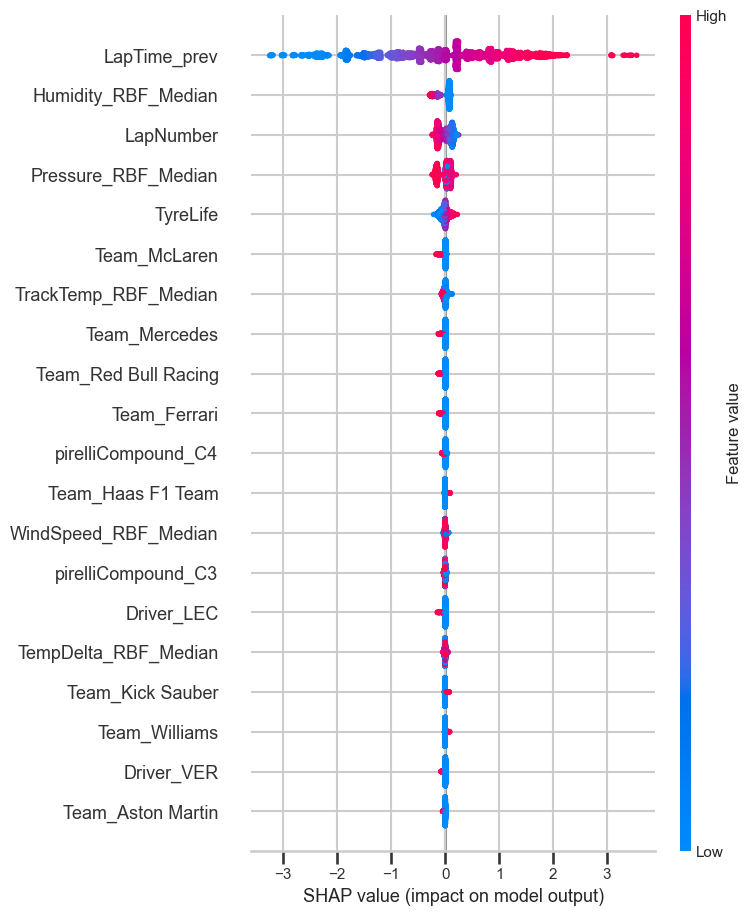

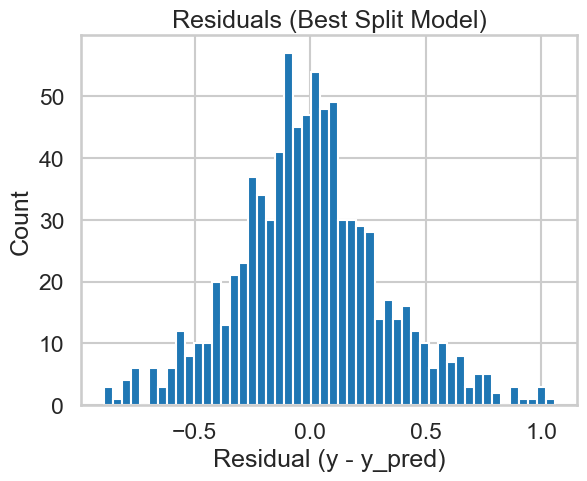

In [31]:
print("\nMelhor modelo do XGBoost treinado durante os splits:")
print("Seed:", best_seed)
print("R2:", best_r2)
print("RMSE:", best_rmse)
print("MAE:", best_mae)

importance = best_model.get_score(importance_type="gain")


if len(importance) > 0 and next(iter(importance.keys())).startswith("f"):
    colnames = list(best_X_tr.columns)
    importance_named = {colnames[int(k[1:])]: v for k, v in importance.items()}
else:
    importance_named = importance

importance_df = (
    pd.DataFrame.from_dict(importance_named, orient="index", columns=["gain"])
      .sort_values("gain", ascending=False)
)

display(importance_df)

shap.initjs()


explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(best_X_tr)

shap.summary_plot(shap_values, best_X_tr)

residuals_best = best_y_te.values - best_preds

plt.figure()
plt.hist(residuals_best, bins=50)
plt.title("Residuals (Best Split Model)")
plt.xlabel("Residual (y - y_pred)")
plt.ylabel("Count")
plt.savefig("residuals_best_model.png", bbox_inches="tight", dpi=300)
plt.show()

## 21. Visualização Definitiva: Comparação de Intervalos de Confiança (95%)

Tabelas numéricas são precisas, mas a visualização gráfica é essencial para a interpretação intuitiva da significância estatística.

Nesta etapa, geramos um gráfico de barras comparativo com **Barras de Erro (*Error Bars*)**, onde:
* **A Altura da Barra:** Representa a **Média** de desempenho nos 5 splits de validação.
* **A Linha Preta (Bigode):** Representa o **Intervalo de Confiança de 95%** (do limite inferior ao superior).

### Como ler este gráfico para a Monografia:
1.  **Teste de Sobreposição (*Overlap Test*):** Olhe para as linhas de erro pretas.
    * Se a linha do Baseline **cruzar** a linha do XGBoost (ou seja, se elas ocuparem a mesma faixa vertical em algum ponto), confirmamos visualmente o **Empate Técnico Estatístico**.
    * Se houver um vão claro entre elas, confirmamos a superioridade de um modelo.
2.  **Consistência:** Barras de erro curtas indicam um modelo estável (que performa igual independente do sorteio dos dados). Barras longas indicam instabilidade.
3.  **Magnitude do Ganho:** Mesmo havendo sobreposição, se a barra do XGBoost for consistentemente menor (no RMSE/MAE) ou maior (no R²), isso ilustra o ganho marginal de precisão obtido pela não-linearidade.

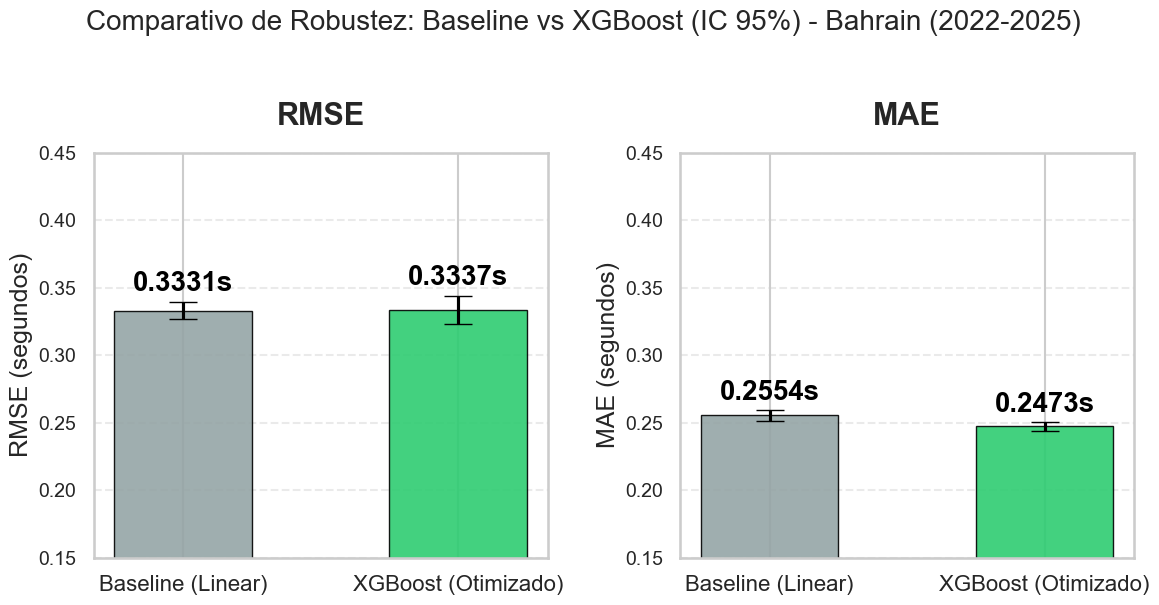

In [32]:
rmse_data = {
    'Baseline (Linear)': [mean_rmse_lr, lower_rmse_lr, upper_rmse_lr],
    'XGBoost (Otimizado)': [rmse_m_xgb, rmse_l_xgb, rmse_u_xgb]
}

mae_data = {
    'Baseline (Linear)': [mean_mae_lr, lower_mae_lr, upper_mae_lr],
    'XGBoost (Otimizado)': [mae_m_xgb, mae_l_xgb, mae_u_xgb]
}

def plot_confidence_intervals(data, metric_name, ax, higher_is_better=False):
    models = list(data.keys())
    means = [data[m][0] for m in models]
    
    yerr = np.array([
        [data[m][0] - data[m][1], data[m][2] - data[m][0]] for m in models
    ]).T

    colors = ['#95a5a6', '#2ecc71'] 

    bars = ax.bar(models, means, yerr=yerr, capsize=10, 
                  color=colors, alpha=0.9, width=0.5, edgecolor='black', linewidth=1)

    for i, bar in enumerate(bars):
        height = bar.get_height()
        upper_limit = data[models[i]][2]
        
        label_pos = upper_limit + (upper_limit * 0.01) 

        label_text = f'{height:.4f}s' 

        ax.text(bar.get_x() + bar.get_width()/2., label_pos,
                label_text, ha='center', va='bottom', fontsize=20, fontweight='bold', color='black')

    ax.set_title(f'{metric_name}', fontsize=22, pad=20, fontweight='bold')
    ax.set_ylabel(f'{metric_name} (segundos)', fontsize=18)
    
    ax.tick_params(axis='x', labelsize=16) 
    ax.tick_params(axis='y', labelsize=14)

    ax.grid(axis='y', linestyle='--', alpha=0.4)
    
    min_val = min(data[m][1] for m in models)
    max_val = max(data[m][2] for m in models)
    
    margin = (max_val - min_val) * 1.5 
    
    ax.set_ylim(0.15, 0.45)

fig, axes = plt.subplots(1, 2, figsize=(12, 6)) 

plot_confidence_intervals(rmse_data, 'RMSE', axes[0], higher_is_better=False)
plot_confidence_intervals(mae_data, 'MAE', axes[1], higher_is_better=False)

plt.suptitle('Comparativo de Robustez: Baseline vs XGBoost (IC 95%) - Bahrain (2022-2025)', fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

In [33]:
def preprocess_like_training(df_raw, cat_cols, num_cols, train_columns):
    Xp = df_raw.copy()

    cat_cols_use = [c for c in cat_cols if c in Xp.columns]
    num_cols_use = [c for c in num_cols if c in Xp.columns]

    Xp[cat_cols_use] = Xp[cat_cols_use].fillna("Missing")

    Xp = pd.get_dummies(Xp, columns=cat_cols_use, drop_first=True)

    Xp[num_cols_use] = Xp[num_cols_use].apply(lambda s: s.fillna(s.median()), axis=0)

    Xp = Xp.reindex(columns=train_columns, fill_value=0)

    return Xp


DRIVER_CODE = "BOR"      
YEAR_TARGET = 2025

RACE_COL = "Race"        
RACE_NAME = 'Hungarian Grand Prix'       

df_all_laps = laps_cleaned.copy() 

mask = (df_all_laps["Year"] == YEAR_TARGET) & (df_all_laps["Driver"] == DRIVER_CODE)

if RACE_NAME is not None and RACE_COL in df_all_laps.columns:
    mask = mask & (df_all_laps[RACE_COL] == RACE_NAME)

df_driver = df_all_laps.loc[mask].copy()

df_driver = df_driver.sort_values("LapNumber")

print("Voltas encontradas:", df_driver.shape[0])
display(df_driver[["Year","Driver","LapNumber",'pirelliCompound','TyreLife']])

Voltas encontradas: 65


,Year,Driver,LapNumber,pirelliCompound,TyreLife
83,2025,BOR,3.0,C4,3.0
123,2025,BOR,4.0,C4,4.0
160,2025,BOR,5.0,C4,5.0
211,2025,BOR,6.0,C4,6.0
264,2025,BOR,7.0,C4,7.0
...,...,...,...,...,...
4441,2025,BOR,66.0,C3,26.0
4513,2025,BOR,67.0,C3,27.0
4586,2025,BOR,68.0,C3,28.0
4659,2025,BOR,69.0,C3,29.0


In [34]:
X_driver_raw = X_raw.loc[df_driver.index].copy()

X_driver_proc = preprocess_like_training(
    df_raw=X_driver_raw,
    cat_cols=cat_cols,             
    num_cols=num_cols_base,        
    train_columns=X.columns       
)

d_driver = xgb.DMatrix(X_driver_proc, feature_names=list(X.columns))
driver_preds = best_model.predict(d_driver)

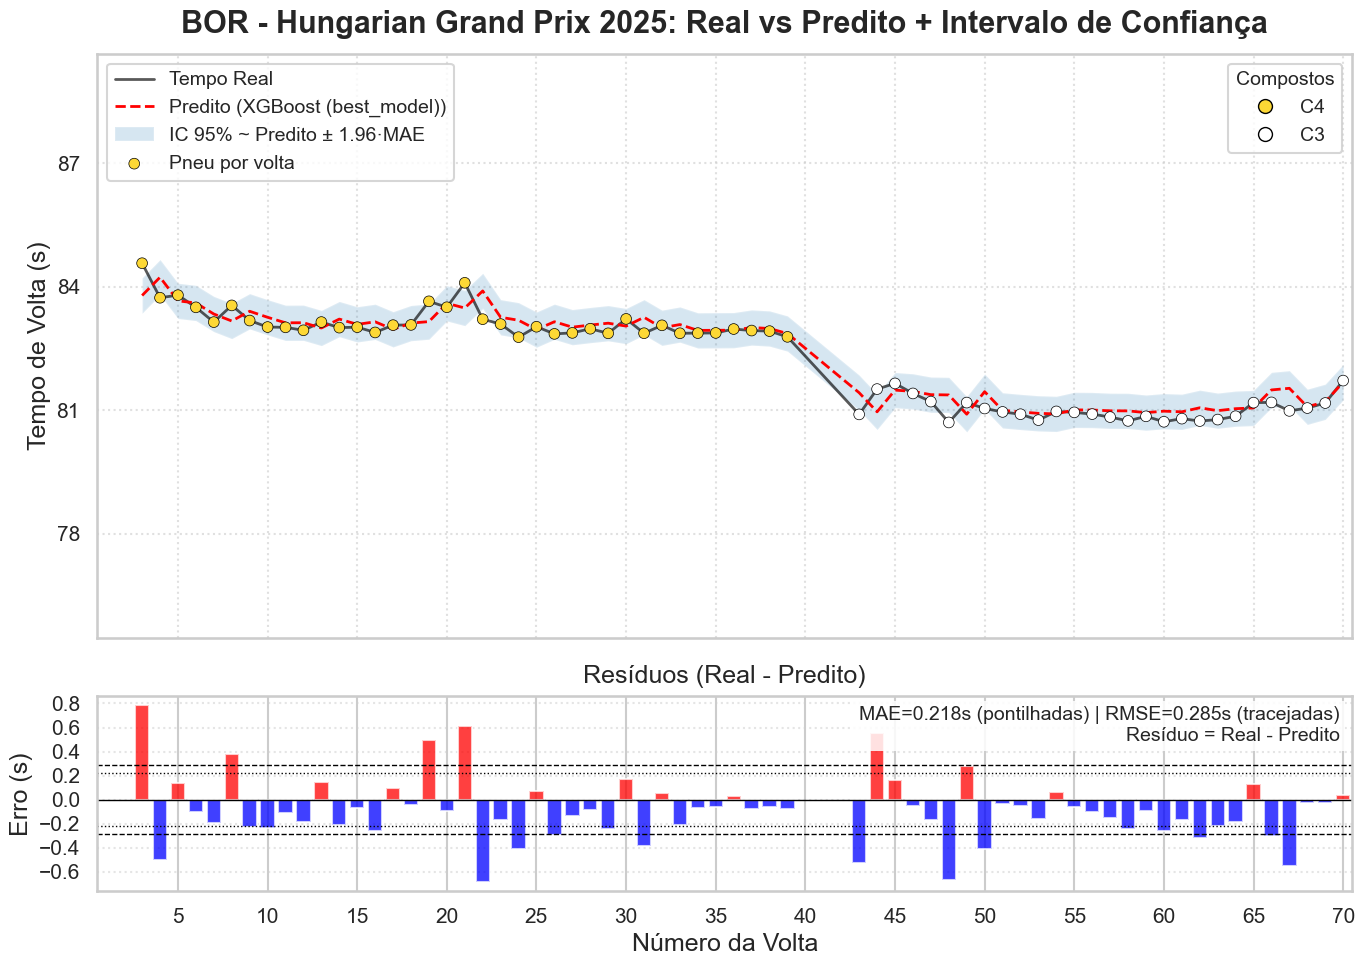

In [35]:
def plot_driver_timeseries_with_ci_combined_mae(
    df_laps, y_true, y_pred,
    tyre_col="pirelliCompound",
    model_label="XGBoost (best_model)",
    title_prefix="DRIVER - RACE 2025",
    y_offset_min=0.5,
    compounds=("C3", "C2", "C1"),
    x_tick_step=5,
    y1_tick_step=3,
    y2_tick_step=0.2,
    ci_level=0.95,          
    ci_method="mae",       
    ci_alpha=0.18
):
    df_plot = df_laps.copy().sort_values("LapNumber").copy()
    df_plot["Real"] = np.array(y_true)
    df_plot["Predito"] = np.array(y_pred)
    df_plot["Residuo"] = df_plot["Real"] - df_plot["Predito"]

    mae = np.mean(np.abs(df_plot["Residuo"]))
    rmse = np.sqrt(np.mean(df_plot["Residuo"] ** 2))

    if tyre_col in df_plot.columns:
        df_plot["Tyre_norm"] = df_plot[tyre_col].astype(str).str.upper().str.strip()
    else:
        df_plot["Tyre_norm"] = "UNK"

    ramp_colors = ["#e53935", "#fdd835", "#ffffff"]
    compounds = tuple([str(c).upper().strip() for c in compounds])
    if len(compounds) != 3:
        raise ValueError("O argumento 'compounds' deve ter exatamente 3 valores.")

    tyre_colors = {compounds[i]: ramp_colors[i] for i in range(3)}
    point_colors = df_plot["Tyre_norm"].map(tyre_colors).fillna("#9e9e9e")

    max_lap = float(df_plot["LapNumber"].max())
    xlim = (0.5, max_lap + 0.5)

    z_map = {0.90: 1.645, 0.95: 1.96, 0.99: 2.576}
    z = z_map.get(ci_level, 1.96) 

    if ci_method == "rmse":
        sigma = rmse
        ci_label = f"IC {int(ci_level*100)}% ~ Predito ± {z:.2f}·RMSE"
    elif ci_method == "mae": 
        sigma = mae
        ci_label = f"IC {int(ci_level*100)}% ~ Predito ± {z:.2f}·MAE"
    elif ci_method == "std":
        sigma = np.std(df_plot["Residuo"], ddof=1)
        ci_label = f"IC {int(ci_level*100)}% ~ Predito ± {z:.2f}·STD"
    else:
        raise ValueError("ci_method deve ser 'rmse', 'mae' ou 'std'.")

    ci_low = df_plot["Predito"] - z * sigma
    ci_high = df_plot["Predito"] + z * sigma

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(14, 10), sharex=True,
        gridspec_kw={"height_ratios": [3, 1]}
    )

    sns.lineplot(
        data=df_plot, x="LapNumber", y="Real", ax=ax1,
        label="Tempo Real", color="black", alpha=0.65, linewidth=2, errorbar=None
    )
    sns.lineplot(
        data=df_plot, x="LapNumber", y="Predito", ax=ax1,
        label=f"Predito ({model_label})", color="red", linestyle="--", linewidth=2, errorbar=None
    )

    ax1.fill_between(
        df_plot["LapNumber"].values,
        ci_low.values,
        ci_high.values,
        alpha=ci_alpha,
        label=ci_label
    )

    ax1.scatter(
        df_plot["LapNumber"], df_plot["Real"],
        c=point_colors, s=60, edgecolors="black", linewidths=0.5, zorder=5,
        label="Pneu por volta"
    )

    ax1.set_title(f"{title_prefix}: Real vs Predito + Intervalo de Confiança", fontsize=22, fontweight='bold', pad=15)
    ax1.set_ylabel("Tempo de Volta (s)", fontsize=18)
    ax1.tick_params(axis='both', which='major', labelsize=15)
    ax1.grid(True, linestyle=":", alpha=0.6)

    y_min = min(df_plot["Real"].min(), df_plot["Predito"].min(), ci_low.min()) - 5
    y_max = max(df_plot["Real"].max(), df_plot["Predito"].max(), ci_high.max()) + 5
    ax1.set_ylim(y_min, y_max)

    tyres_present = set(df_plot["Tyre_norm"].unique())
    ordered_tyres = [t for t in compounds if t in tyres_present]
    extras = sorted([t for t in tyres_present if t not in compounds])
    ordered_tyres += extras

    compound_handles = [
        Line2D([0], [0], marker="o", linestyle="", markersize=10,
               markerfacecolor=tyre_colors.get(t, "#9e9e9e"),
               markeredgecolor="black", label=t)
        for t in ordered_tyres
    ]

    leg_main = ax1.legend(loc="upper left", fontsize=14)
    leg_comp = ax1.legend(handles=compound_handles, title="Compostos", loc="upper right", frameon=True, fontsize=14, title_fontsize=14)
    ax1.add_artist(leg_main)

    ax1.set_xlim(*xlim)
    ax1.xaxis.set_major_locator(MultipleLocator(x_tick_step))
    ax1.yaxis.set_major_locator(MultipleLocator(y1_tick_step))

    colors = np.where(df_plot["Residuo"] >= 0, "red", "blue")
    ax2.bar(df_plot["LapNumber"], df_plot["Residuo"], color=colors, alpha=0.75)
    ax2.axhline(0, color="black", linewidth=1)

    ax2.axhline(+mae, color="black", linestyle=":", linewidth=1)
    ax2.axhline(-mae, color="black", linestyle=":", linewidth=1)
    ax2.axhline(+rmse, color="black", linestyle="--", linewidth=1)
    ax2.axhline(-rmse, color="black", linestyle="--", linewidth=1)

    ax2.text(
        0.99, 0.95,  
        f"MAE={mae:.3f}s (pontilhadas) | RMSE={rmse:.3f}s (tracejadas)\nResíduo = Real - Predito",
        transform=ax2.transAxes, 
        fontsize=14, 
        ha="right",   
        va="top",  
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="none")
    )

    ax2.set_title("Resíduos (Real - Predito)", fontsize=18, pad=10)
    ax2.set_ylabel("Erro (s)", fontsize=18)
    ax2.set_xlabel("Número da Volta", fontsize=18)
    ax2.tick_params(axis='both', which='major', labelsize=15)
    
    ax2.grid(True, axis="y", linestyle=":", alpha=0.5)
    ax2.set_xlim(*xlim)
    ax2.xaxis.set_major_locator(MultipleLocator(x_tick_step))
    ax2.yaxis.set_major_locator(MultipleLocator(y2_tick_step))

    fig.tight_layout()
    plt.show()

    return df_plot

df_driver_plot = plot_driver_timeseries_with_ci_combined_mae(
    df_laps=df_driver,
    y_true=df_driver[target_col].values,
    y_pred=driver_preds,
    title_prefix=f"{DRIVER_CODE} - {RACE_NAME} 2025",
    compounds=("C5", "C4", "C3"),
    y_offset_min=0.5,
    ci_level=0.95,
    ci_method="mae"  
)

In [36]:
years = sorted(X_raw['Year'].unique())  # [2022, 2023, 2024, 2025]
loyo_results = {"year_holdout": [], "rmse": [], "mae": [], "r2": []}

for holdout_year in years:
    X_train_loyo = X_proc[X_raw['Year'] != holdout_year]
    X_test_loyo = X_proc[X_raw['Year'] == holdout_year]
    y_train_loyo = y_raw[X_raw['Year'] != holdout_year]
    y_test_loyo = y_raw[X_raw['Year'] == holdout_year]
    
    # Treinar com best_params do Optuna
    dtr = xgb.DMatrix(X_train_loyo, label=y_train_loyo)
    dte = xgb.DMatrix(X_test_loyo, label=y_test_loyo)
    
    bst = xgb.train(
        params=optuna_params_train,
        dtrain=dtr,
        num_boost_round=5000,
        evals=[(dte, "validation")],
        early_stopping_rounds=100,
        verbose_eval=False
    )
    preds = bst.predict(dte)
    
    loyo_results["year_holdout"].append(holdout_year)
    loyo_results["rmse"].append(np.sqrt(mean_squared_error(y_test_loyo, preds)))
    loyo_results["mae"].append(mean_absolute_error(y_test_loyo, preds))
    loyo_results["r2"].append(r2_score(y_test_loyo, preds))

print("\n--- Resultados LOYO por Ano ---")
for i in range(len(years)):
    print(f"Ano Holdout: {loyo_results['year_holdout'][i]} | RMSE: {loyo_results['rmse'][i]:.4f} | MAE: {loyo_results['mae'][i]:.4f} | R2: {loyo_results['r2'][i]:.4f}")
    


--- Resultados LOYO por Ano ---
Ano Holdout: 2022 | RMSE: 0.4582 | MAE: 0.3460 | R2: 0.8379
Ano Holdout: 2023 | RMSE: 0.3638 | MAE: 0.2865 | R2: 0.8861
Ano Holdout: 2024 | RMSE: 0.3733 | MAE: 0.2931 | R2: 0.9037
Ano Holdout: 2025 | RMSE: 0.9020 | MAE: 0.7608 | R2: 0.4208


In [39]:
LAP_COL = "LapNumber"
WINDOW_RATIO = 0.15
TRAIN_RATIO = 0.80
TEST_RATIO = 0.20
SLIDE_STEP = 1

if LAP_COL not in X_raw.columns:
    raise ValueError(f"Coluna '{LAP_COL}' nao encontrada em X_raw.")

lap_min = int(X_raw[LAP_COL].min())
lap_max = int(X_raw[LAP_COL].max())
total_laps = lap_max - lap_min + 1

window_laps = max(2, int(np.round(total_laps * WINDOW_RATIO)))
train_size = max(1, int(np.floor(window_laps * TRAIN_RATIO)))
test_size = max(1, window_laps - train_size)

if train_size + test_size > window_laps:
    test_size = window_laps - train_size
if test_size < 1:
    test_size = 1
    train_size = window_laps - 1

print(f"Range de voltas disponivel: {lap_min}..{lap_max}")
print(f"Total de voltas: {total_laps}")
print(
    f"Janela universal = {WINDOW_RATIO:.0%} da corrida => {window_laps} voltas | "
    f"train_size = {train_size} ({TRAIN_RATIO:.0%}) | test_size = {test_size} ({TEST_RATIO:.0%})"
)

wf_results = {
    "fold": [],
    "window_range": [],
    "train_range": [],
    "test_range": [],
    "n_train": [],
    "n_test": [],
    "best_iter": [],
    "rmse": [],
    "mae": [],
    "r2": []
}

fold = 1
window_start = lap_min
window_last_start = lap_max - window_laps + 1

while window_start <= window_last_start:
    window_end = window_start + window_laps - 1
    train_start = window_start
    train_end = train_start + train_size - 1
    test_start = train_end + 1
    test_end = window_end

    mask_train = (X_raw[LAP_COL] >= train_start) & (X_raw[LAP_COL] <= train_end)
    mask_test = (X_raw[LAP_COL] >= test_start) & (X_raw[LAP_COL] <= test_end)

    X_train_wf = X_proc.loc[mask_train]
    y_train_wf = y_raw.loc[mask_train]
    X_test_wf = X_proc.loc[mask_test]
    y_test_wf = y_raw.loc[mask_test]

    if len(X_train_wf) > 0 and len(X_test_wf) > 0:
        dtr = xgb.DMatrix(X_train_wf, label=y_train_wf)
        dte = xgb.DMatrix(X_test_wf, label=y_test_wf)

        num_boost_round = int(best_n) if "best_n" in globals() and best_n else 500

        bst = xgb.train(
            params=optuna_params_train,
            dtrain=dtr,
            num_boost_round=num_boost_round,
            verbose_eval=False
        )

        preds = bst.predict(dte)

        rmse_val = np.sqrt(mean_squared_error(y_test_wf, preds))
        mae_val = mean_absolute_error(y_test_wf, preds)
        r2_val = r2_score(y_test_wf, preds)

        wf_results["fold"].append(fold)
        wf_results["window_range"].append(f"{window_start}-{window_end}")
        wf_results["train_range"].append(f"{train_start}-{train_end}")
        wf_results["test_range"].append(f"{test_start}-{test_end}")
        wf_results["n_train"].append(len(X_train_wf))
        wf_results["n_test"].append(len(X_test_wf))
        wf_results["best_iter"].append(int(num_boost_round))
        wf_results["rmse"].append(float(rmse_val))
        wf_results["mae"].append(float(mae_val))
        wf_results["r2"].append(float(r2_val))

        print(
            f"Fold {fold:02d} | Janela {window_start}-{window_end} | "
            f"Train {train_start}-{train_end} | Test {test_start}-{test_end} | "
            f"n_train={len(X_train_wf)} n_test={len(X_test_wf)} | "
            f"RMSE={rmse_val:.4f} MAE={mae_val:.4f} R2={r2_val:.4f}"
        )
        fold += 1

    window_start += SLIDE_STEP


df_wf = pd.DataFrame(wf_results)

print("\n--- Resumo Walk-Forward Universal ---")
display(df_wf)

if len(df_wf) > 1:
    print("Medias globais:")
    print(f"RMSE medio: {df_wf['rmse'].mean():.4f}")
    print(f"MAE  medio: {df_wf['mae'].mean():.4f}")
    print(f"R2   medio: {df_wf['r2'].mean():.4f}")
else:
    print("Poucos folds para media robusta.")

Range de voltas disponivel: 3..70
Total de voltas: 68
Janela universal = 15% da corrida => 10 voltas | train_size = 8 (80%) | test_size = 2 (20%)
Fold 01 | Janela 3-12 | Train 3-10 | Test 11-12 | n_train=524 n_test=148 | RMSE=0.3123 MAE=0.2459 R2=0.9201
Fold 02 | Janela 4-13 | Train 4-11 | Test 12-13 | n_train=549 n_test=150 | RMSE=0.3594 MAE=0.2806 R2=0.9021
Fold 03 | Janela 5-14 | Train 5-12 | Test 13-14 | n_train=569 n_test=143 | RMSE=0.3625 MAE=0.2832 R2=0.9051
Fold 04 | Janela 6-15 | Train 6-13 | Test 14-15 | n_train=569 n_test=131 | RMSE=0.3253 MAE=0.2460 R2=0.9253
Fold 05 | Janela 7-16 | Train 7-14 | Test 15-16 | n_train=564 n_test=122 | RMSE=0.3703 MAE=0.2821 R2=0.9099
Fold 06 | Janela 8-17 | Train 8-15 | Test 16-17 | n_train=562 n_test=118 | RMSE=0.3492 MAE=0.2719 R2=0.9277
Fold 07 | Janela 9-18 | Train 9-16 | Test 17-18 | n_train=554 n_test=117 | RMSE=0.3621 MAE=0.2776 R2=0.9321
Fold 08 | Janela 10-19 | Train 10-17 | Test 18-19 | n_train=543 n_test=119 | RMSE=0.3521 MAE=0.261

,fold,window_range,train_range,test_range,n_train,n_test,best_iter,rmse,mae,r2
0,1,3-12,3-10,11-12,524,148,741,0.312343,0.245894,0.920104
1,2,4-13,4-11,12-13,549,150,741,0.359437,0.280565,0.902127
2,3,5-14,5-12,13-14,569,143,741,0.362487,0.283151,0.905112
3,4,6-15,6-13,14-15,569,131,741,0.325346,0.245983,0.925272
4,5,7-16,7-14,15-16,564,122,741,0.370290,0.282112,0.909873
5,6,8-17,8-15,16-17,562,118,741,0.349155,0.271920,0.927746
6,7,9-18,9-16,17-18,554,117,741,0.362102,0.277556,0.932052
7,8,10-19,10-17,18-19,543,119,741,0.352118,0.261648,0.933097
8,9,11-20,11-18,19-20,530,123,741,0.356082,0.277943,0.922865
9,10,12-21,12-19,20-21,518,124,741,0.356358,0.283014,0.920173


Medias globais:
RMSE medio: 0.3809
MAE  medio: 0.2852
R2   medio: 0.9214
